# DAF-16: The Metric That Matches Asha's Decision — Walk-Forward Evaluation

## The story

Asha is the school coordinator. Every evening at 18:00 she decides whether 600 children go outside tomorrow. The model gives her a number, and she turns it into one of two actions: **outside** or **indoors**.

So far we graded the model with MAE, the average size of its mistakes. Asha does not feel an average. She feels two very different evenings:

- **A false alarm.** The model says Poor, the air is fine. The children stay in for a day. Annoying, but nobody is hurt.
- **A missed Poor day.** The model says fine, the air is Poor. 600 children breathe it for a whole afternoon. This is the one that ends up in a parent's complaint.

MAE counts these two mistakes the same. A model can have a nice MAE and still miss the days that matter.

There is a second problem. Every score so far came from **one cut date**, 2026-03-01. The test period was spring and summer, only 17 Poor days, and Delhi's real danger season was in the training half. One exam on one kind of weather does not tell Asha how the model behaves in November.

DAF-16 fixes both: it judges the model on **Asha's decision**, and it tests it **month after month** the way it would really be used.

## What this ticket is about

Two changes to how we score a model. The model itself does not change.

```text
Before                                    After
one cut date, one test period             many monthly exams, each on unseen days
MAE as the headline                       recall and false alarms as the headline
"how far off on average?"                 "did Asha warn on the Poor days?"
```

Backend analogy: MAE is like reporting average latency. Recall on Poor days is like reporting how many real outages your alert caught. Average latency can look healthy while the alert system misses the one outage that mattered. Walk-forward evaluation is like replaying last year's traffic day by day against a system that only knew the past, instead of load-testing it once.

## The decision view

Every forecast becomes Asha's action with the CPCB table (D-001): a forecast of **91 or above** means warn, anything below means all-clear. Put the forecast against what really happened and every day lands in one of four boxes:

| | Actually Poor or worse | Actually below 91 |
|---|---|---|
| **Forecast Poor or worse** | correct warning | false alarm |
| **Forecast below 91** | **missed Poor day — the dangerous one** | correct all-clear |

Two numbers come out of this table:

- **Recall** = correct warnings ÷ all actual Poor days. *Of the days I should have warned on, how many did I?*
- **Precision** = correct warnings ÷ all warnings. *When I warned, how often was I right?*

Recall protects the children. Precision protects Asha's credibility: a model that cries wolf every week stops being believed.

## Walk-forward evaluation

Pick a start date. Train on everything **before** it, predict the next month, then move forward one month, retrain, and repeat.

```text
step 1   train |■■■■■■■■■■■■|  test |□□□□|
step 2   train |■■■■■■■■■■■■■■■■|  test |□□□□|
step 3   train |■■■■■■■■■■■■■■■■■■■■|  test |□□□□|
                          time  ───────────────────────►
```

The training window grows each step (an *expanding window*), and every month is scored by a model that never saw it. This is exactly how the service will live: each month, retrain on all the history, forecast the next days.

What it tells us that one cut date cannot: how the model does in **each season**, including winter, and how much the score wobbles from month to month.

**An honest limit.** The data starts in February 2025, so there is only **one winter** (Nov 2025 to Feb 2026). When walk-forward reaches that winter, the model has never seen a winter. That is a realistic, hard test, and we will say so when we read the results.

## Moving the warning line

If the model misses Poor days, it can warn earlier: instead of warning when the forecast reaches 91, warn at 80. Recall goes up, and so do false alarms.

```text
warn at 100  →  few false alarms, more missed Poor days
warn at  91  →  the official line
warn at  70  →  few missed Poor days, many false alarms
```

This is a **product decision**, not a modelling trick: it is Asha choosing how many cancelled outdoor days she will accept to avoid one missed Poor day. If we move the line, it is recorded as **D-007**.

The trap: maximising recall alone. A model that always says "indoors" has perfect recall and is useless. We always read recall **with** false alarms per month.

## The three models

We compare the best model of each kind from the earlier tickets, all using the same four features.

| Model | From | Why it is here |
|---|---|---|
| Persistence | DAF-06 | The floor. "Tomorrow = today so far." Any model must beat this |
| Ridge, `daf14_selected` | DAF-14 | Best model so far: MAE 15.588, caught 12 of 17 Poor days |
| Best tree model | DAF-15 | Random forest had the best MAE of the three trees (18.900). The decision tree caught more Poor days but with MAE 25.1 |

Features: `pm25_until_17`, `mean_3`, `mean_7`, `mean_14`. Persistence uses only `pm25_until_17`.

## Rules for this ticket

- **No future inside the loop.** At every step the scaler, the feature selection and the model are fitted on the training window only. Features are built from past days, so a row never contains information from after its own 18:00.
- **Settings are fixed before the loop.** No hyper-parameter is chosen by looking at walk-forward scores. DAF-17 tunes. Here we only evaluate.
- **Warning line 91 first.** Every number is reported at the official line before we explore moving it.
- Every experiment-log row is marked `walk-forward`, because these scores are **not comparable** with the single-cut rows from earlier tickets: different test days, different method.

### The rules, as a picture

![The four rules of DAF-16](figures/16_rules.png)

Rule 1 is the one that matters most. Picture Asha on 30 November, testing December. She may only use what she knew that day. If the scaler is computed on all rows, it has already "seen" December, and the test stops being a test.

## The plan, one step at a time

1. Write one scoring function: MAE, recall, precision and the confusion matrix for any predictions.
2. Rebuild the feature table, and choose the walk-forward start date.
3. Write the walk-forward loop: monthly steps, expanding window, retrain each step.
4. Run it for persistence, Ridge and the random forest. Report metrics per month and overall, with the confusion matrix for the best model.
5. Plot recall per month for the three.
6. Try warning lines from 70 to 100. Plot recall and false alarms against the line.
7. Decide whether to move the line, and record D-007 if we do.
8. Add the `walk-forward` rows to `reports/experiments.csv`.

We will do one step at a time. Step 1 comes next.

### The plan, as a picture

![The eight steps of DAF-16](figures/16_plan.png)

Read it left to right, top to bottom. Steps 1 to 4 build and run the exam. Steps 5 to 7 read the results and make Asha's decision. Step 8 writes the evidence down. The two blue cards are where the real thinking happens.

# Step 1 — One scoring function for Asha's decision

## 🎬 How we got here

Every score so far was an MAE, plus a recall that we worked out by hand, in a slightly different way, inside each notebook. In DAF-15 the `score` function lived inside Step 2 and only returned three numbers.

Asha now wants to judge models on **her decision**. Walk-forward will score a model twelve times, once per month, for three models. Doing that by copy-pasting scoring code would be slow, and one typo would quietly change a result.

## 😖 The problem

MAE treats every mistake by its **size**. Asha cares about its **direction**. Here are two days from a small example we will build in this step:

```text
            what really happened    what the model said    error     what it meant for Asha
Day 3       Poor (95)               90 -> "fine"            only 5    MISSED Poor day. Children outside in bad air.
Day 2       fine (60)               95 -> "Poor"            35        false alarm. Children stay in for a day.
```

The dangerous day has the **small** error (5). The harmless day has the **big** error (35). An average of errors cannot tell them apart. We need to count the two kinds of mistake separately.

## 💡 The idea

Write **one function** that takes the real PM2.5 values and the forecasts, and returns everything Asha needs in one go. Every later step calls it and nothing else.

```text
actual PM2.5  ──┐                              ┌─► MAE          (size of mistakes)
                ├─► score_forecasts(...) ──────┼─► recall       (Poor days caught)
forecast PM2.5 ─┘                              ├─► precision    (warnings that were right)
                                               └─► 4 counts     (the confusion matrix)
```

The four counts come from putting each day in one box:

```text
                          REALLY Poor (>= 91)        REALLY fine (< 91)
  Model said Poor    │   TP  correct warning     │   FP  false alarm          │
  Model said fine    │   FN  MISSED Poor day     │   TN  correct all-clear    │
```

Backend analogy: this is your alerting dashboard. TP is an outage that paged you. FN is an outage that **did not** page you. FP is a page for no outage. MAE is like "average CPU", useful but not what wakes anyone up.

## 🔍 What this actually is

- **Two lines, not one.** `poor_line` (default 91) decides what **really** counts as a Poor day. `warn_at` (default 91) decides when the model **warns**. For now they are equal. In Step 6 we move only `warn_at`, and the truth stays fixed.
- **Recall and precision can be undefined.** A month with no Poor day has nothing to catch, so recall would be 0 ÷ 0. The function returns `NaN` (not a number) instead of a fake 0 or 1. A month with no warnings has the same problem for precision. Walk-forward will hit both cases, so this matters.
- **Counts, not only ratios.** With about 17 Poor days, one day moves recall by 0.06. The counts are always returned next to the ratios, so nobody over-reads a small difference.

### 🤔 Before you run the code

In the 8-day example, the model warns on 5 days and there are 4 really Poor days. Can you guess how many of the 4 it caught? Then read the result.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, mean_absolute_error


def score_forecasts(actual, predicted, poor_line=91, warn_at=91):
    """Score forecasts the way Asha uses them: size of error, and right / wrong warnings."""
    # --- 1. Plain arrays of numbers, so lists, Series and arrays all work ---------
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    assert actual.shape == predicted.shape, "actual and predicted must have the same length"

    # --- 2. Turn numbers into yes / no answers --------------------------------------
    really_poor = actual >= poor_line      # what happened: was it a Poor day?
    warned = predicted >= warn_at          # what the model said: did it warn?

    # --- 3. Count each of the four boxes ----------------------------------------------
    tp = int((really_poor & warned).sum())     # Poor day, model warned
    fn = int((really_poor & ~warned).sum())    # Poor day, model stayed quiet  <- dangerous
    fp = int((~really_poor & warned).sum())    # fine day, model warned
    tn = int((~really_poor & ~warned).sum())   # fine day, model stayed quiet

    # --- 4. Ratios. Dividing by zero means "undefined", so return NaN ---------------
    n_poor = tp + fn                           # all really Poor days
    n_warnings = tp + fp                       # all warnings
    recall = tp / n_poor if n_poor else np.nan
    precision = tp / n_warnings if n_warnings else np.nan

    return {
        "mae": mean_absolute_error(actual, predicted),
        "recall": recall,
        "precision": precision,
        "tp": tp, "fn": fn, "fp": fp, "tn": tn,
        "n_days": len(actual), "n_poor": n_poor,
    }


def confusion_table(result):
    """The four counts as the 2x2 table Asha reads."""
    return pd.DataFrame(
        [[result["tp"], result["fp"]], [result["fn"], result["tn"]]],
        index=["Model said Poor", "Model said fine"],
        columns=["Really Poor", "Really fine"],
    )

### What this code does

| Part | What it does |
|---|---|
| `score_forecasts(actual, predicted, ...)` | The one function every later step will call |
| `really_poor`, `warned` | Two lists of True / False, one entry per day. Everything else is counting them |
| `&` and `~` | `&` means "and". `~` means "not". `really_poor & ~warned` reads "really Poor and the model did not warn" |
| `nan` when dividing by zero | Keeps "no Poor days this month" different from "caught none of them" |
| `confusion_table(result)` | Shows the four counts in the same 2x2 layout as the picture above |

Nothing has run on real data yet. Next we try it on 8 days small enough to check by hand.

In [2]:
# --- An 8-day example small enough to check with a pencil ---------------------------
days = pd.DataFrame(
    {
        "actual":   [45, 60, 95, 120, 70, 100, 85, 150],   # the real PM2.5 of each day
        "forecast": [50, 95, 90, 130, 60, 105, 92, 110],   # what the model said
    },
    index=pd.RangeIndex(1, 9, name="day"),                 # label the days 1..8
)

toy = score_forecasts(days["actual"], days["forecast"])

# --- Show each day with the box it landed in ------------------------------------------
days["really Poor?"] = days["actual"] >= 91
days["warned?"] = days["forecast"] >= 91
days["box"] = np.select(
    [days["really Poor?"] & days["warned?"],
     days["really Poor?"] & ~days["warned?"],
     ~days["really Poor?"] & days["warned?"]],
    ["TP correct warning", "FN MISSED", "FP false alarm"],
    default="TN all-clear",
)
display(days)

print(f"MAE {toy['mae']:.3f} | recall {toy['recall']:.2f} ({toy['tp']} of {toy['n_poor']} Poor days) "
      f"| precision {toy['precision']:.2f} ({toy['tp']} of {toy['tp'] + toy['fp']} warnings)")
display(confusion_table(toy))

# --- Check our function against scikit-learn's own confusion matrix ---------------------
# sklearn lists the "fine" class first, so its layout is [[TN, FP], [FN, TP]].
tn, fp, fn, tp = confusion_matrix(days["really Poor?"], days["warned?"]).ravel()
assert (tn, fp, fn, tp) == (toy["tn"], toy["fp"], toy["fn"], toy["tp"])
print("matches scikit-learn's confusion matrix")

,actual,forecast,really Poor?,warned?,box
day,,,,,
1,45,50,False,False,TN all-clear
2,60,95,False,True,FP false alarm
3,95,90,True,False,FN MISSED
4,120,130,True,True,TP correct warning
5,70,60,False,False,TN all-clear
6,100,105,True,True,TP correct warning
7,85,92,False,True,FP false alarm
8,150,110,True,True,TP correct warning


MAE 14.625 | recall 0.75 (3 of 4 Poor days) | precision 0.60 (3 of 5 warnings)


,Really Poor,Really fine
Model said Poor,3,2
Model said fine,1,2


matches scikit-learn's confusion matrix


### Read the result

The model warned on 5 days and there were 4 really Poor days. It caught **3 of the 4** (recall 0.75), and 3 of its 5 warnings were right (precision 0.60).

- **Day 3 is the missed Poor day.** Real 95, forecast 90. It is only 5 off, so it barely moves MAE, but it is the one that matters.
- **Days 2 and 7 are false alarms.** Day 2 (forecast 95, real 60) is 35 off. Day 7 (forecast 92, real 85) is only 7 off, yet it still cost a cancelled outdoor day. Even a small error can cross the line.
- The last line checks our function against scikit-learn's confusion matrix. We wrote our own because we need `poor_line` and `warn_at` apart, and because we want `NaN` for "no Poor days".

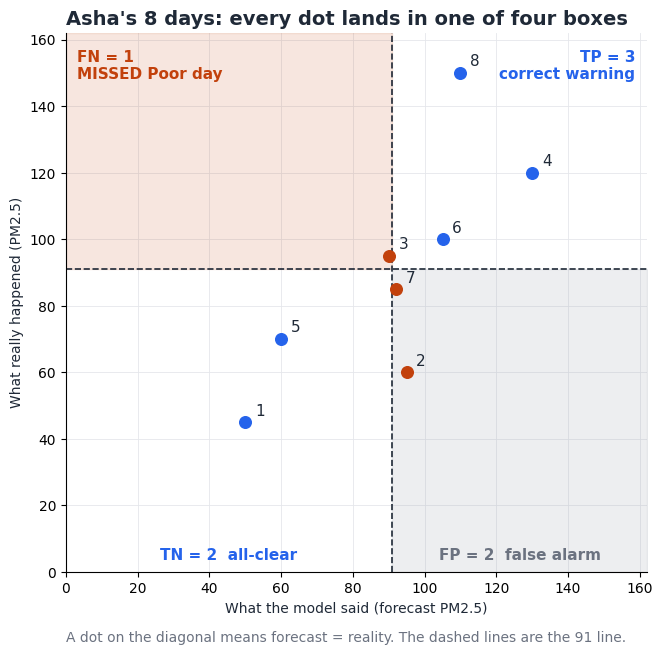

In [3]:
import matplotlib.pyplot as plt

# Same look as the other DAF figures: grey plus one blue accent, orange-red only for problems.
INK, MUTED, GRID = "#1f2937", "#6b7280", "#e5e7eb"
ACCENT, ALERT = "#2563eb", "#c2410c"


def draw_boxes(ax, actual, predicted, line=91, label_days=False):
    """Forecast on the x axis, what really happened on the y axis, one dot per day."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    top = max(actual.max(), predicted.max()) * 1.08

    # Shade the two problem boxes: the dangerous one (missed) and the harmless-but-annoying one.
    ax.fill_between([0, line], line, top, color=ALERT, alpha=0.13)        # FN: said fine, really Poor
    ax.fill_between([line, top], 0, line, color="#9ca3af", alpha=0.18)    # FP: said Poor, really fine
    ax.axvline(line, color=INK, lw=1.2, ls="--")
    ax.axhline(line, color=INK, lw=1.2, ls="--")

    really_poor, warned = actual >= line, predicted >= line
    correct = (really_poor == warned)
    ax.scatter(predicted[correct], actual[correct], s=70, color=ACCENT, zorder=3, label="correct")
    ax.scatter(predicted[~correct], actual[~correct], s=70, color=ALERT, zorder=3, label="mistake")
    if label_days:
        for day, (x, y) in enumerate(zip(predicted, actual), start=1):
            ax.annotate(str(day), (x, y), textcoords="offset points", xytext=(7, 5), fontsize=11, color=INK)

    # Name each box with its count, so the picture and the table say the same thing.
    counts = {
        "TP": int((really_poor & warned).sum()), "FN": int((really_poor & ~warned).sum()),
        "FP": int((~really_poor & warned).sum()), "TN": int((~really_poor & ~warned).sum()),
    }
    ax.text(top * 0.02, top * 0.97, f"FN = {counts['FN']}\nMISSED Poor day", ha="left", va="top", color=ALERT, fontsize=11, fontweight="bold")
    ax.text(top * 0.98, top * 0.97, f"TP = {counts['TP']}\ncorrect warning", ha="right", va="top", color=ACCENT, fontsize=11, fontweight="bold")
    ax.text(line + (top - line) / 2, line * 0.03, f"FP = {counts['FP']}  false alarm", ha="center", va="bottom", color=MUTED, fontsize=11, fontweight="bold")
    ax.text(line * 0.5, line * 0.03, f"TN = {counts['TN']}  all-clear", ha="center", va="bottom", color=ACCENT, fontsize=11, fontweight="bold")
    ax.set_xlim(0, top); ax.set_ylim(0, top)
    ax.set_xlabel("What the model said (forecast PM2.5)", color=INK)
    ax.set_ylabel("What really happened (PM2.5)", color=INK)
    ax.grid(color=GRID, lw=0.6); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


fig, ax = plt.subplots(figsize=(7.5, 7))
draw_boxes(ax, days["actual"], days["forecast"], label_days=True)
ax.set_title("Asha's 8 days: every dot lands in one of four boxes", loc="left", fontsize=14, fontweight="bold", color=INK)
ax.text(0, -0.13, "A dot on the diagonal means forecast = reality. The dashed lines are the 91 line.", transform=ax.transAxes, fontsize=10, color=MUTED)
plt.show()

### Read the picture

Each dot is one day. The **dashed lines** are the 91 line: left of the vertical one the model said "fine", below the horizontal one the day really was fine.

- A dot in the **top-left** box is Day 3, the missed Poor day. It sits only just to the left of the line, so the model was close, but close is not enough when the line decides the action.
- The dots in the **bottom-right** box are the two false alarms, Days 2 and 7.
- Every blue dot is a correct call, on either side. The four box counts add up to 8 days.

Now the same function and the same picture on the real test days.

Persistence on 130 test days: MAE 16.791 | recall 0.471 (8 of 17) | precision 0.400


,Really Poor,Really fine
Model said Poor,8,12
Model said fine,9,101


matches the persistence row from DAF-15 (MAE 16.791, 8 of 17 Poor days caught)


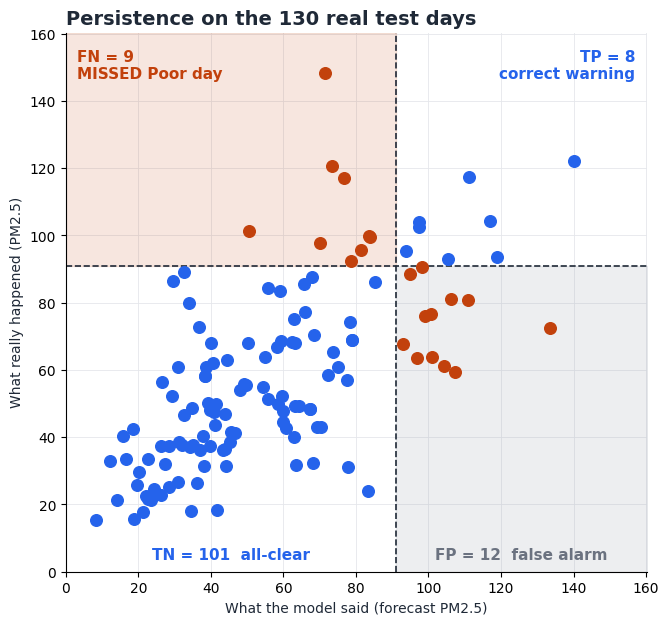

In [4]:
from pathlib import Path

# --- 1. Find the project's data folder (works from the repo root or from the project) ----
project_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "data/interim/daily_17.csv").is_file()
    or (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
)
data_root = (
    project_root / "data"
    if (project_root / "data/interim/daily_17.csv").is_file()
    else project_root / "18_Projects/01_Delhi_Air_Forecast/data"
)

# --- 2. The same daily table and the same 130 test days as DAF-15 -------------------------
daily = pd.read_csv(data_root / "interim/daily_17.csv", parse_dates=["date"], index_col="date")
if daily.index.tz is not None:                               # plain Delhi calendar days, no clock time
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

from delhi_air.clean import add_rolling_features             # our own function from src/delhi_air/clean.py

feature_names = ["pm25_until_17", "mean_3", "mean_7", "mean_14"]   # fixed before any model, as in DAF-15
model_table = add_rolling_features(daily)[feature_names + ["target"]].dropna()
test = model_table.loc[model_table.index >= pd.Timestamp("2026-03-01")]
assert len(test) == 130, "not the same 130 test days as DAF-15"

# --- 3. Persistence: "tomorrow = what today looks like so far" ----------------------------
persistence = score_forecasts(test["target"], test["pm25_until_17"])
print(f"Persistence on {persistence['n_days']} test days: MAE {persistence['mae']:.3f} | "
      f"recall {persistence['recall']:.3f} ({persistence['tp']} of {persistence['n_poor']}) | "
      f"precision {persistence['precision']:.3f}")
display(confusion_table(persistence))

# --- 4. It must match DAF-15's re-scored persistence row, or the function is wrong --------
assert round(persistence["mae"], 3) == 16.791 and persistence["tp"] == 8 and persistence["n_poor"] == 17
print("matches the persistence row from DAF-15 (MAE 16.791, 8 of 17 Poor days caught)")

fig, ax = plt.subplots(figsize=(7.5, 7))
draw_boxes(ax, test["target"], test["pm25_until_17"])
ax.set_title("Persistence on the 130 real test days", loc="left", fontsize=14, fontweight="bold", color=INK)
plt.show()

### Read the result

Persistence warned on 20 days and was right on 8 of them. The function **reproduces DAF-15's persistence numbers exactly** (MAE 16.791, 8 of 17 Poor days caught), so we can trust it before walk-forward relies on it.

What the new view adds, which MAE never showed:

- **Precision 0.40.** Only 8 of the 20 warnings were real. Asha would have cancelled 12 outdoor days for nothing.
- **9 missed Poor days**, the top-left box. Look at where they sit: they run from just over the line (real 92) up to the worst day of the test period (real 148), and every one had a forecast under 91. Persistence only knows today's hours up to 17:00, so it is blind to a day that turns worse overnight.
- **Recall 0.471** is the share of the top row that was caught: 8 of 17.

Not one mistake here is averaged away. That is what Asha asked for.

## Before Step 2

Step 1 gave us the ruler: `score_forecasts` returns MAE, recall, precision and the four counts for any forecasts, and `confusion_table` shows them as a 2x2. It passed two checks: a hand-worked 8-day example, and DAF-15's persistence row.

Step 2 rebuilds the feature table over the whole history and chooses the walk-forward start date. Before we can loop over months, we need to know which months exist and how many Poor days each has.

# Step 2 — The whole table, month by month, and the start date

## 🎬 How we got here

Step 1 gave Asha a ruler, `score_forecasts`. Now she needs something to measure. Walk-forward will test the models one **month** at a time, so before writing any loop she needs to know what each month actually contains.

## 😖 The problem

In DAF-15 the split was one cut date, 2026-03-01, and the test half was spring and summer. The picture of "how many Poor days" was a single number: 17. Walk-forward cuts the year into months, and a month can be nothing like its neighbour. If Asha does not look first, she will meet these surprises **inside** the loop, where they are hard to see:

```text
a month with 0 Poor days    ->  recall = 0 ÷ 0, undefined
a month with 9 usable days  ->  one day moves the score a lot
a start date too early      ->  the first models train on almost nothing
a start date too late       ->  the winter never gets tested
```

## 💡 The idea

Build the feature table **once** for the whole history, count the days and the Poor days in each month, and only then choose the start date.

```text
daily_17.csv
     │  add the 4 features (all look backwards only)
     ▼
model_table: one row per usable day, 381 rows
     │  group by month
     ▼
days and Poor days per month  ──►  choose the start date
                                   everything before it  = first training window
                                   every month from it   = one monthly exam
```

Backend analogy: before replaying last year's traffic against a system, you look at the traffic first. You check for empty hours, for the week the logging broke, and for the peak, and then you choose where the replay starts.

## 🔍 What this actually is

- **Same 4 features as DAF-15:** `pm25_until_17`, `mean_3`, `mean_7`, `mean_14`. They were fixed before any model was fitted, and they stay fixed.
- **Is building features once a leak?** The ticket warns about "a feature computed once on all rows before looping". That is only a leak when a feature looks at the **future**, for example a scaler fitted on all rows. Our rolling means use yesterday and earlier. A row's value is the same whether we build the table once or rebuild it on the day. The second code cell **proves** this on real dates instead of just claiming it.
- **The start date is a choice.** It is a constant at the top of the cell, so it is easy to change. We choose it with the numbers in front of us.

### 🤔 Before you run the code

The data has one winter, and the test half in DAF-15 held only 17 Poor days out of 130. Predict: how many Poor days do you expect in November and December? Then read the table.

In [5]:
# Continues from Step 1: daily, model_table, feature_names, score_forecasts.

# --- 1. Two settings for this ticket, written down before any model runs ---------------
poor_line = 91                           # PM2.5 at or above this is a Poor day (CPCB, D-001)
walk_start = pd.Timestamp("2025-10-01")  # first month to be tested; everything before it is the first training window

# --- 2. Count days and Poor days in each calendar month ----------------------------------
table = model_table.assign(poor=model_table["target"] >= poor_line)   # True on a really Poor day
month = table.index.to_period("M")                                    # "2025-10", "2025-11", ...
by_month = table.groupby(month).agg(
    days=("target", "size"),             # usable days in the month
    poor_days=("poor", "sum"),           # how many of them were really Poor
    mean_pm25=("target", "mean"),        # how bad the month was on average
)
by_month["share_poor"] = by_month["poor_days"] / by_month["days"]
# Mark each month: "train only" lies wholly before the start date, "tested" is scored by walk-forward.
by_month["role"] = np.where(by_month.index.to_timestamp() < walk_start, "train only", "tested")
display(by_month.round({"mean_pm25": 1, "share_poor": 2}))

# --- 3. What the first model will see, and what the loop will test ---------------------------
first_train = table.loc[table.index < walk_start]
tested = table.loc[table.index >= walk_start]
print(f"first training window: {len(first_train)} days, {int(first_train['poor'].sum())} Poor "
      f"({first_train.index.min().date()} to {first_train.index.max().date()})")
print(f"tested by the loop:    {len(tested)} days, {int(tested['poor'].sum())} Poor, "
      f"in {tested.index.to_period('M').nunique()} monthly exams")
no_poor = by_month.index[(by_month["role"] == "tested") & (by_month["poor_days"] == 0)]
print("tested months with 0 Poor days (recall will be undefined):", ", ".join(str(m) for m in no_poor))

# --- 4. Safety checks: stop loudly if the table is not the one DAF-15 used -------------------
assert len(table) == 381 and int(table["poor"].sum()) == 134, "table differs from DAF-15's 251 + 130 rows"

,days,poor_days,mean_pm25,share_poor,role
date,,,,,
2025-03,14,4,77.2,0.29,train only
2025-04,8,4,96.5,0.50,train only
2025-05,15,2,73.3,0.13,train only
2025-06,13,1,61.0,0.08,train only
2025-07,26,3,54.9,0.12,train only
2025-08,29,0,40.7,0.00,train only
2025-09,30,0,41.8,0.00,train only
2025-10,29,18,142.7,0.62,tested
2025-11,29,29,238.8,1.00,tested


first training window: 135 days, 14 Poor (2025-03-17 to 2025-09-30)
tested by the loop:    246 days, 120 Poor, in 11 monthly exams
tested months with 0 Poor days (recall will be undefined): 2026-06, 2026-07, 2026-08


### Read the result

| | Days | Poor days | Share Poor |
|---|---:|---:|---:|
| First training window (Mar to Sep 2025) | 135 | 14 | 10% |
| Tested by the loop (Oct 2025 to Aug 2026) | 246 | 120 | 49% |

Four things stand out:

- **November and December are all Poor.** 29 of 29 usable days in each. In those two months there is no fine day at all, so there can be no false alarm, and the only thing left to judge is recall. January is 9 of 9 for the same reason.
- **The first model has never seen a winter.** Its 135 training days hold only 14 Poor days, and its single worst day is 251. A typical December day averages 247 and the worst reaches 458, so it has met one bad day but never a whole month of them. This is the hard, honest test. A model that has only seen the monsoon is asked about the smog. Expect it to under-predict at first, and expect the random forest to be the most stuck, because a forest cannot predict higher than the highest target it was trained on.
- **Three tested months have no Poor days** (June, July and August 2026). Their recall is undefined, and `score_forecasts` returns `NaN` for them, which is exactly why Step 1 was written that way. Their MAE and false alarms still count.
- **January has 9 usable days and August 7.** The sensor was down from 10 to 19 January, and `mean_14` needs 14 clean days in a row, so about a month of rows is lost. August has 7 because the sensor again has missing days (11 of them) and the same 14-day rule costs more rows. Monthly scores on 7 to 9 days are noisy, so we read them with the day counts beside them.

In [6]:
# --- Prove that building the features once does not leak the future -------------------------
# For a few real dates, pretend today IS that date: throw away every later day, rebuild the
# features from what is left, and compare with the value from the full table.
rolling_columns = ["mean_3", "mean_7", "mean_14"]
full_features = add_rolling_features(daily)               # built once, on every row

rows = []
for date in ["2025-06-09", "2025-10-16", "2025-12-15", "2026-03-16"]:
    assert pd.Timestamp(date) in model_table.index, f"{date} is not a usable day"
    only_the_past = daily.loc[:date]                       # nothing after `date` exists
    rebuilt = add_rolling_features(only_the_past).loc[date, rolling_columns].astype(float)   # .astype: the table mixes bool and float columns
    from_full = full_features.loc[date, rolling_columns].astype(float)
    rows.append({"date": date, **{f"{c} (full)": from_full[c] for c in rolling_columns},
                 "identical": bool(np.allclose(rebuilt, from_full))})
    assert np.allclose(rebuilt, from_full), f"features at {date} depend on later rows"

display(pd.DataFrame(rows).set_index("date").round(2))
print("every feature is identical when the future is removed, so one build is safe")

,mean_3 (full),mean_7 (full),mean_14 (full),identical
date,,,,
2025-06-09,77.20,60.66,61.66,True
2025-10-16,95.37,82.38,68.24,True
2025-12-15,365.38,251.78,235.94,True
2026-03-16,77.42,97.43,98.63,True


every feature is identical when the future is removed, so one build is safe


### Read the result

All four dates give identical features whether the future is present or not. A rolling mean over yesterday and earlier **cannot** know about tomorrow, so building the table once and slicing it by date is safe.

This is **not** true for everything. The scaler and the feature selector in the Ridge pipeline learn from the data, so they must be fitted again inside every step of the loop, on that step's training days only. That is Rule 1 from the top of the notebook, and the loop in Step 3 will do exactly that.

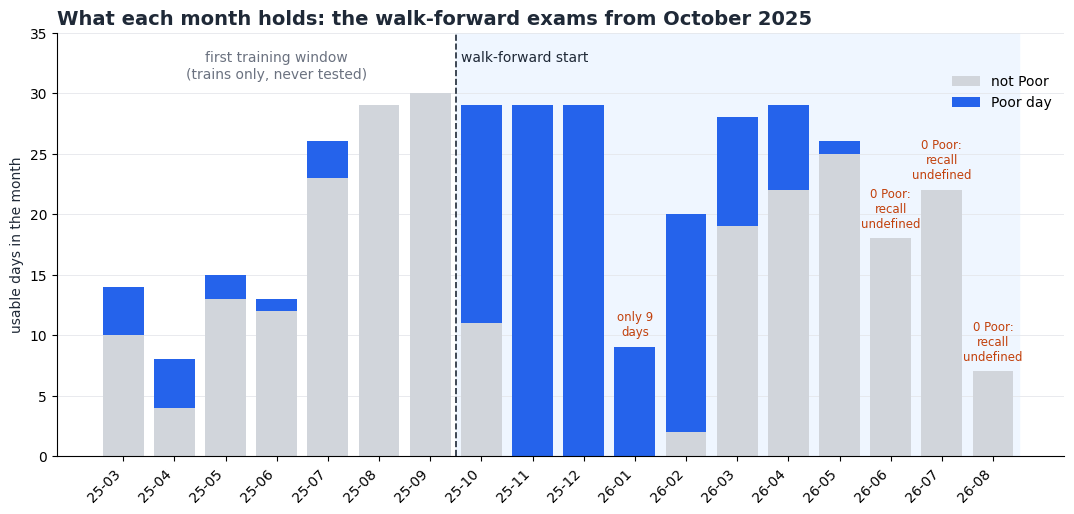

In [7]:
import matplotlib.pyplot as plt

# Same palette as Step 1: grey plus one blue accent, orange-red only for a problem with a text label.
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(by_month))
tested_mask = (by_month["role"] == "tested").to_numpy()

# Each bar is one month. Grey = days that were not Poor, blue = Poor days.
ax.bar(x, by_month["days"] - by_month["poor_days"], color="#d1d5db", label="not Poor")
ax.bar(x, by_month["poor_days"], bottom=by_month["days"] - by_month["poor_days"], color=ACCENT, label="Poor day")

# Shade the months the loop will test, and label the start date.
first_test = int(np.argmax(tested_mask))
ax.axvspan(first_test - 0.5, len(x) - 0.5, color="#eff6ff", zorder=0)
ax.axvline(first_test - 0.5, color=INK, ls="--", lw=1.2)
ax.text(first_test - 0.4, 33.5, "walk-forward start", color=INK, fontsize=10, va="top")
ax.text(first_test / 2 - 0.5, 33.5, "first training window\n(trains only, never tested)", ha="center", va="top", color=MUTED, fontsize=10)

# Label the months where a score will be shaky, so nobody over-reads them.
for i, (name, row) in enumerate(by_month.iterrows()):
    if tested_mask[i] and row["poor_days"] == 0:
        ax.text(i, row["days"] + 0.7, "0 Poor:\nrecall\nundefined", ha="center", va="bottom", fontsize=8.5, color=ALERT)
    elif tested_mask[i] and row["days"] < 12:
        ax.text(i, row["days"] + 0.7, f"only {int(row['days'])}\ndays", ha="center", va="bottom", fontsize=8.5, color=ALERT)

ax.set_xticks(x)
ax.set_xticklabels([str(m)[2:] for m in by_month.index], rotation=45, ha="right")
ax.set_ylim(0, 35)
ax.set_ylabel("usable days in the month", color=INK)
ax.set_title("What each month holds: the walk-forward exams from October 2025", loc="left", fontsize=14, fontweight="bold", color=INK)
ax.grid(axis="y", color=GRID, lw=0.6); ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.93))
plt.show()

### Read the picture

Grey and blue together are the usable days in a month, and the blue part is the Poor days. Read it from left to right and you can watch Delhi's year: almost no blue through the monsoon, a sudden jump in October, a solid wall of blue in November and December, and a slow fade to nothing by June.

The dashed line is the walk-forward start, **1 October 2025**.

### Why 1 October, and what we gave up

| Start date | First training window | Tested months | The catch |
|---|---|---|---|
| 1 September | 105 days, 14 Poor | 12 | Adds September, which has 0 Poor days: nothing to score, and the first model trains on less |
| **1 October (chosen)** | **135 days, 14 Poor** | **11** | The smog arrives in the first exam, so we see how a model without any winter experience copes |
| 1 November | 164 days, 32 Poor | 10 | Drops October, the month the air turns. The most useful early-warning month is never tested |

October gives the first model seven months to learn from and still tests the whole winter. We lose nothing the ticket asked for, and every later change of the date is one line (`walk_start`).

## Before Step 3

Step 2 told us what the exams contain: 11 monthly exams, 246 days, 120 Poor, three months where recall is undefined and two with fewer than 10 days.

Step 3 writes the walk-forward loop: for each month from October, fit on every earlier day, predict that month, and keep the forecasts. It is the heart of the ticket, so we will write it carefully and test it before we trust it.

# Step 3 — The walk-forward loop

## 🎬 How we got here

Step 1 built the ruler, `score_forecasts`. Step 2 showed what the exams contain: 381 usable days, the first 135 only for training, then 11 monthly exams over 246 days, starting 1 October 2025.

Now Asha needs the forecasts themselves: one prediction for each of those 246 days, made the way the service would really make it.

## 😖 The problem

The obvious way is to train once on everything and predict all 246 days. That is cheating, and it cheats in the exact place Asha cares about:

```text
Cheating                                   Honest
train on ALL 381 days                      to forecast 15 Dec 2025, the model may use
predict 15 Dec 2025                        only days before 1 Dec 2025
                                           (and 1 Dec gets its own model with Nov in it)
   |                                          |
   v                                          v
the model saw the real answer              the model never saw December
for that very day                          when it forecast December
"great score" = it memorised               a score Asha can believe
```

A single cut date (DAF-15) avoids the cheat, but it gives one exam on one kind of weather. We want the honest version repeated for **every month**.

## 💡 The idea

A loop over the months. Each pass is one exam:

```text
for each month from October 2025 to August 2026:
    train  = every usable day BEFORE this month starts
    test   = the days IN this month
    model  = a brand-new model          (not the one from last month)
    model.fit(train)                    (it learns from the past only)
    forecasts for the month = model.predict(test)     (kept; scored later, in Step 4)
```

Every model goes through the **same** function, including persistence. Persistence "learns" nothing, but we give it a `fit` and a `predict` like the others. That way there is one loop, and the three models cannot be treated differently by accident.

Backend analogy: this is a time-travelling replay. You rebuild the service as it was on the first of each month, feed it only the logs that existed then, and record what it would have said. Then you compare with what really happened.

See pictures 4 and 5 in `16_visual_walkthrough.ipynb`.

## 🔍 What this actually is

| Part | Choice | Why |
|---|---|---|
| Train window | everything strictly before the month starts (expanding) | Rule 1: the past only |
| Fresh model each month | `clone(model)` | An old model must not carry anything over. `clone` returns an unfitted copy with the same settings |
| Persistence | `pm25_until_17` is the forecast | The floor to beat. No fitting |
| Ridge | `StandardScaler` + `Ridge(alpha=1.0, solver="lsqr")` | The DAF-14 model. The scaler is part of the pipeline, so it is refitted on each month's training days |
| Random forest | defaults, `random_state=0` | The DAF-15 model. Not tuned (Rule 2) |
| Features | the same four as before | Fixed before the loop (Rule 2) |

The loop only **collects forecasts**. Scoring them is Step 4.

**An honest limit.** DAF-14 chose these four features by looking at training days up to February 2026, which includes the winter we are now testing. They are four plain averages of PM2.5, so the effect should be small, but the early exams (October to February) are not perfectly clean on feature choice. We will say so when we read the results.

### 🤔 Before you run the code

After the loop is built we will scramble every row from 1 January 2026 onward, then run it again. Will the **October, November and December** forecasts change? Predict first. The answer is the whole point of the loop.

In [8]:
import warnings

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Continues from Steps 1 and 2: model_table, feature_names, walk_start.


# --- 1. Persistence as a model with fit / predict, so it can use the same loop -----------
class Persistence(BaseEstimator, RegressorMixin):
    """'Tomorrow will be like today so far.' It learns nothing, but looks like every other model."""

    def fit(self, X, y):
        return self                              # nothing to learn

    def predict(self, X):
        return X["pm25_until_17"].to_numpy()     # the forecast IS today's reading so far


# --- 2. The three models, with settings fixed BEFORE the loop (Rule 2) -----------------------
models = {
    "persistence": Persistence(),
    "ridge": Pipeline([                          # DAF-14's model: scale, then a straight line
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0, solver="lsqr")),
    ]),
    "random_forest": Pipeline([                  # DAF-15's model, default settings
        ("model", RandomForestRegressor(random_state=0)),
    ]),
}

### What this code does

| Part | What it does |
|---|---|
| `class Persistence(...)` | A tiny model. `fit` does nothing and `predict` returns the `pm25_until_17` column. `BaseEstimator` is what lets `clone` copy it |
| `models` | A dictionary of **unfitted** models. Nothing is trained here. The loop will train a fresh copy each month |
| Ridge inside a `Pipeline` | The scaler and the Ridge are fitted together on the training days. Each month the scaler's average is computed again from that month's training days only |

Nothing has run on data yet. Next is the loop itself.

In [9]:
def walk_forward(table, model, features, start, target="target"):
    """Forecast every month from `start` with a model trained only on the days before that month."""
    first_month = pd.Period(start, freq="M")                  # e.g. 2025-10
    last_month = table.index.max().to_period("M")             # last month that has data
    pieces = []

    for month in pd.period_range(first_month, last_month, freq="M"):
        month_start = month.start_time                        # 00:00 on the 1st
        next_month_start = (month + 1).start_time             # 00:00 on the 1st of the next month

        # --- 1. Split by TIME. Train = strictly before the month. Test = inside the month -----
        train = table.loc[table.index < month_start]
        test = table.loc[(table.index >= month_start) & (table.index < next_month_start)]
        if test.empty:                                        # a month with no usable days
            continue
        # Safety check: every training day is earlier than every test day.
        assert len(train) > 0 and train.index.max() < test.index.min()

        # --- 2. A brand-new model each month; it learns from the past only ---------------------
        fresh = clone(model)                                  # unfitted copy, same settings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)   # same harmless numpy notice as DAF-14
            fresh.fit(train[features], train[target])
            predicted = fresh.predict(test[features])

        # --- 3. Keep the forecasts, with what really happened beside them ------------------------
        pieces.append(
            pd.DataFrame(
                {
                    "month": str(month),
                    "train_rows": len(train),                 # how much history this exam had
                    "actual": test[target].to_numpy(),
                    "predicted": predicted,
                },
                index=test.index,
            )
        )
    return pd.concat(pieces)

### What this code does

| Part | What it does |
|---|---|
| `pd.period_range(...)` | Lists the months from October 2025 to the last month with data |
| `month.start_time`, `(month + 1).start_time` | The first moment of this month and of the next. They draw the test window |
| `train = ... index < month_start` | The past only. This one line is Rule 1 |
| `assert train.index.max() < test.index.min()` | Stops the notebook if the split is ever wrong |
| `clone(model)` | A fresh, unfitted copy every month. The old fitted model is thrown away |
| the returned table | One row per tested day: `month`, `train_rows`, `actual`, `predicted`. No scoring yet |

In [10]:
# --- 1. Run the same loop for all three models ----------------------------------------------
forecasts = {name: walk_forward(model_table, model, feature_names, walk_start) for name, model in models.items()}

# --- 2. What did each exam look like? Same for every model, so show Ridge's -----------------------
steps = forecasts["ridge"].groupby("month").agg(train_rows=("train_rows", "first"), test_days=("actual", "size"))
display(steps)

# --- 3. Safety checks: stop loudly if the loop did not do what Step 2 promised --------------------
for name, table_ in forecasts.items():
    assert len(table_) == 246, f"{name}: expected the 246 tested days from Step 2"
    assert table_.index.min() >= walk_start                              # nothing before the start date
    assert table_.index.equals(forecasts["ridge"].index)                 # all three models: the same days
assert steps["train_rows"].iloc[0] == 135                                # first exam: the 135-day window
assert steps["train_rows"].is_monotonic_increasing                       # the window only ever grows
assert steps["test_days"].sum() == 246 and len(steps) == 11
print("3 models x 246 days, 11 exams, the training window grew every month")

display(forecasts["ridge"].head(4).round(1))   # first four forecasts: made with 135 days of history

,train_rows,test_days
month,,
2025-10,135,29
2025-11,164,29
2025-12,193,29
2026-01,222,9
2026-02,231,20
2026-03,251,28
2026-04,279,29
2026-05,308,26
2026-06,334,18


3 models x 246 days, 11 exams, the training window grew every month


,month,train_rows,actual,predicted
date,,,,
2025-10-02,2025-10,135,46.1,54.7
2025-10-03,2025-10,135,80.8,48.7
2025-10-04,2025-10,135,81.5,58.0
2025-10-05,2025-10,135,38.6,59.9


In [11]:
# --- The test that matters: does the future change the past? --------------------------------------
# Scramble EVERY row from 1 Jan 2026 (features and target), run the loop again, and compare the
# October to December forecasts. If the loop only uses the past, they cannot change.
future_start = pd.Timestamp("2026-01-01")
scrambled = model_table.copy()
scrambled.loc[scrambled.index >= future_start, feature_names + ["target"]] = 9999.0

for name, model in models.items():
    again = walk_forward(scrambled, model, feature_names, walk_start)
    before = forecasts[name].loc[forecasts[name].index < future_start, "predicted"]
    after = again.loc[again.index < future_start, "predicted"]
    assert len(before) == 87 and np.allclose(before, after), f"{name}: the future changed the past"
    print(f"{name:14s} Oct-Dec forecasts (87 days) identical after scrambling 2026: True")

# --- And a deliberately LEAKY version, to show the test would notice -----------------------------
# Here the scaler is fitted ONCE on all rows before the loop (the trap named in the ticket).
def leaky_ridge(table):
    features = table[feature_names]
    scaled = pd.DataFrame(StandardScaler().fit_transform(features), index=table.index, columns=feature_names)
    scaled["target"] = table["target"]
    return walk_forward(scaled, Ridge(alpha=1.0, solver="lsqr"), feature_names, walk_start)

early = lambda frame: frame.loc[frame.index < future_start, "predicted"]
gap = (early(leaky_ridge(model_table)) - early(leaky_ridge(scrambled))).abs().max()
print(f"leaky Ridge: biggest change in an Oct-Dec forecast after scrambling 2026 = {gap:.1f}  (the test catches it)")
assert gap > 1

persistence    Oct-Dec forecasts (87 days) identical after scrambling 2026: True
ridge          Oct-Dec forecasts (87 days) identical after scrambling 2026: True


random_forest  Oct-Dec forecasts (87 days) identical after scrambling 2026: True
leaky Ridge: biggest change in an Oct-Dec forecast after scrambling 2026 = 204.5  (the test catches it)


In [12]:
# --- A first look at the forecasts: the average per month (not a score, just a look) -----------
monthly_average = pd.DataFrame(
    {"really happened": forecasts["ridge"].groupby("month")["actual"].mean()}
    | {name: table_.groupby("month")["predicted"].mean() for name, table_ in forecasts.items()}
)
display(monthly_average.round(0))

,really happened,persistence,ridge,random_forest
month,,,,
2025-10,143.0,129.0,97.0,67.0
2025-11,239.0,232.0,227.0,199.0
2025-12,247.0,215.0,231.0,224.0
2026-01,172.0,158.0,205.0,211.0
2026-02,118.0,117.0,131.0,211.0
2026-03,83.0,80.0,93.0,84.0
2026-04,70.0,71.0,76.0,74.0
2026-05,55.0,54.0,61.0,61.0
2026-06,42.0,43.0,50.0,59.0


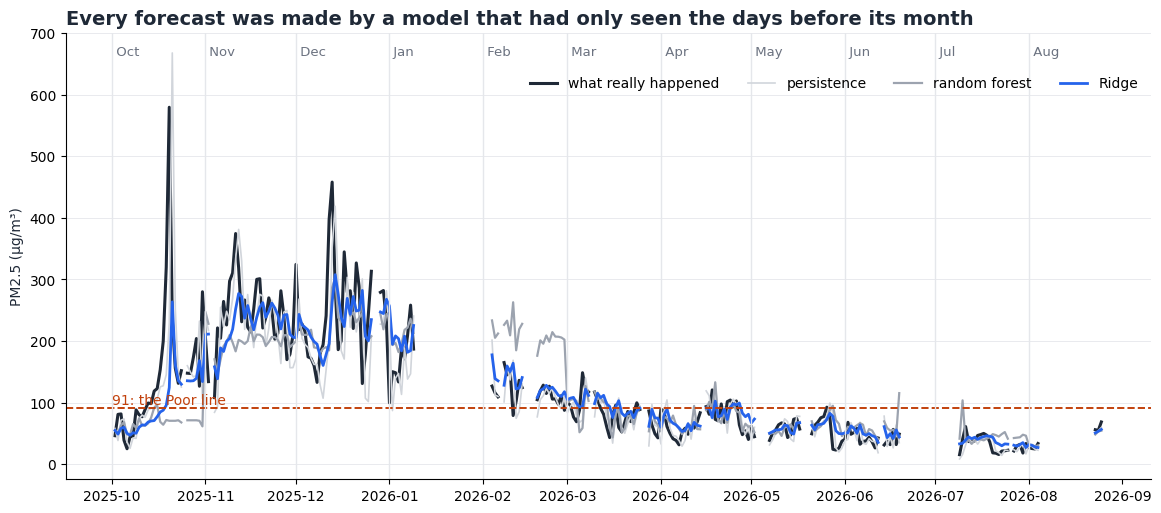

In [13]:
import matplotlib.pyplot as plt

# Palette from Step 1: ink for the truth, one blue accent, greys for the rest.
fig, ax = plt.subplots(figsize=(14, 5.8))
every_day = pd.date_range(walk_start, forecasts["ridge"].index.max())     # leave gaps where the sensor was down

actual_line = forecasts["ridge"]["actual"].reindex(every_day)
ax.plot(actual_line, color=INK, lw=2.2, label="what really happened")
ax.plot(forecasts["persistence"]["predicted"].reindex(every_day), color="#d1d5db", lw=1.2, label="persistence")
ax.plot(forecasts["random_forest"]["predicted"].reindex(every_day), color="#9ca3af", lw=1.6, label="random forest")
ax.plot(forecasts["ridge"]["predicted"].reindex(every_day), color=ACCENT, lw=2, label="Ridge")
ax.axhline(poor_line, color=ALERT, ls="--", lw=1.4)
ax.text(every_day[0], poor_line + 6, "91: the Poor line", color=ALERT, fontsize=10)

# Mark where each monthly exam begins: the model changes on each dashed line.
for month_start in pd.date_range(walk_start, every_day[-1], freq="MS"):
    ax.axvline(month_start, color="#e5e7eb", lw=1)
    ax.text(month_start, ax.get_ylim()[1] * 0.97, month_start.strftime(" %b"), fontsize=9.5, color=MUTED, va="top")

ax.set_ylabel("PM2.5 (µg/m³)", color=INK)
ax.set_title("Every forecast was made by a model that had only seen the days before its month", loc="left", fontsize=14, fontweight="bold", color=INK)
ax.grid(axis="y", color=GRID, lw=0.6); ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, ncol=4, loc="upper right", bbox_to_anchor=(1, 0.93))
plt.show()

### Read the result

**The loop is honest.** Nothing from 2026 reached the October to December forecasts: all three models gave identical forecasts after we scrambled 2026. The leaky Ridge, with its scaler fitted once on every row, changed by up to 204 µg/m³ in the same test. So the test would have caught the trap, and our loop passes it.

**What the table and the picture already show**, before any score:

- **October is the hard month, as Step 2 warned.** Really happened: 143 on average, with a peak of 579. Ridge averaged 97 and peaked at 263. The random forest averaged only 67 and **never forecast above 95**. Its 135 training days were mostly low (only 14 Poor), so its trees mostly answer "low". A model that has never seen a smoggy month cannot warn about one.
- **November and December are easier.** By then the training window contains October, and all three models track the level (really happened 239 and 247, Ridge 227 and 231). They still miss the sharpest peaks, which sit well above 300.
- **February shows the opposite problem.** Really happened: 118. The random forest forecast 211, because the days just before February were all smoggy and it expects winter to continue. Ridge (131) and persistence (117) follow the real fall much better.
- **The picture has gaps.** The sensor was down in January, and a few other weeks are missing, so the lines stop and restart. A month with 7 or 9 scored days will give shaky numbers, as we saw in Step 2.

Nothing is scored yet. The same 246 days are now sitting in three tables, ready for Step 4.

## Before Step 4

Step 3 produced `forecasts`: for each of the three models, one forecast for each of the 246 days, each made by a model that had seen only earlier months.

Step 4 scores them with `score_forecasts` from Step 1: MAE, recall, precision and the confusion matrix, per month and overall, with the best model's confusion matrix shown.

# Step 4 — Score the forecasts, month by month and overall

## 🎬 How we got here

Step 3 produced `forecasts`: three tables, one forecast for each of the 246 tested days, each made by a model that had seen only the months before. Not one of them has been scored.

## 😖 The problem

A table of 246 forecasts is not an answer. Asha needs to know two things, and one number cannot give both:

```text
"How good is the model overall?"          one number for all 246 days
"Where does it fail?"                     one number per month, so she can see the October smog
```

There is also a trap in combining the monthly numbers. Suppose the model caught 12 of 18 Poor days in October and 29 of 29 in November:

```text
average of the two percentages:   (0.67 + 1.00) / 2   = 0.83     <- treats a month of 18 like a month of 29
add up the counts, then divide:   (12 + 29) / (18 + 29) = 0.87    <- every Poor day counts once
```

Asha cares about **days**, not months. The overall score must be worked out from the counts.

## 💡 The idea

Use the Step 1 ruler twice on the same forecasts:

```text
forecasts (246 days)
      |
      +--> score_forecasts on each month separately  -->  "where does it fail?"
      |
      +--> score_forecasts on all 246 days at once   -->  "how good overall?"  (counts added up for us)
```

Because `score_forecasts` works from counts, calling it on all 246 days at once is exactly "add up the counts, then divide". Nothing extra to write.

## 🔍 What this actually is

- **Same line, same ruler.** Warn at 91, and "really Poor" is 91 or more. Nothing moves yet (that is Step 6).
- **The best model is chosen by a rule written now.** Best = the lowest overall MAE and the highest overall recall. If the two disagree, we show both and say so. We do not pick after looking at which one we like.
- **Some months cannot be scored fully.** June to August 2026 have no Poor day, so their recall is `NaN`. November, December and January have no fine day, so a false alarm is impossible there and precision looks perfect for free. We read those months with that in mind.
- **Each month is a small sample.** A month with 9 days (January) or 7 (August) can swing a lot. The day counts are shown beside every score.

### 🤔 Before you run the code

In **October**, when the smog starts and no model has ever seen a smoggy month, which of the three will catch the most Poor days: persistence, Ridge or the random forest? Predict first.

In [14]:
# Continues from Step 3: forecasts (one table per model), plus score_forecasts and confusion_table from Step 1.

# --- 1. Score every model, month by month ------------------------------------------------------------
rows = []
for name, table_ in forecasts.items():
    for month, part in table_.groupby("month"):                  # one exam at a time
        rows.append({"model": name, "month": month, **score_forecasts(part["actual"], part["predicted"])})
by_month = pd.DataFrame(rows)

# --- 2. Score every model on all 246 days at once = "add up the counts, then divide" -----------------
overall = {name: score_forecasts(table_["actual"], table_["predicted"]) for name, table_ in forecasts.items()}

# --- 3. Safety check: the monthly counts must add up to the overall counts ---------------------------
for name in forecasts:
    mine = by_month[by_month["model"] == name]
    for box in ("tp", "fn", "fp", "tn"):
        assert mine[box].sum() == overall[name][box], f"{name}: {box} does not add up"
print("monthly counts add up to the overall counts for all three models")

# --- 4. The overall table ---------------------------------------------------------------------------------
overall_table = pd.DataFrame(overall).T[["mae", "recall", "precision", "tp", "fn", "fp", "tn"]]
overall_table[["tp", "fn", "fp", "tn"]] = overall_table[["tp", "fn", "fp", "tn"]].astype(int)
display(overall_table.round(3))

monthly counts add up to the overall counts for all three models


,mae,recall,precision,tp,fn,fp,tn
persistence,35.352,0.858,0.880,103,17,14,112
ridge,30.379,0.908,0.901,109,11,12,114
random_forest,41.485,0.792,0.872,95,25,14,112


### What this code does

| Part | What it does |
|---|---|
| `groupby("month")` | Splits one model's forecasts into its 11 exams |
| `score_forecasts(part["actual"], part["predicted"])` | The Step 1 ruler, used on one exam |
| `overall = {...}` | The same ruler on all 246 days. Counts are added up before dividing |
| the `assert` loop | If the 11 monthly counts did not sum to the overall counts, the notebook stops |
| `overall_table` | One row per model: MAE, recall, precision, and the four boxes |

In [15]:
# --- Per-month tables: one column per model, one row per exam -----------------------------------------
days_per_month = by_month[by_month["model"] == "ridge"].set_index("month")[["n_days", "n_poor"]]


def month_table(column):
    """One score per month and model, with the day counts beside it."""
    wide = by_month.pivot(index="month", columns="model", values=column)[list(forecasts)]
    return days_per_month.join(wide)


mae_by_month = month_table("mae")
recall_by_month = month_table("recall")
false_alarms_by_month = month_table("fp")

print("MAE (average size of the mistake, lower is better)")
display(mae_by_month.round(1))
print("Recall (Poor days caught / Poor days). '-' = no Poor day that month, so there is nothing to catch")
display(recall_by_month.style.format("{:.2f}", subset=list(forecasts), na_rep="-"))
print("False alarms (days the model warned and the air was fine)")
display(false_alarms_by_month.astype({name: int for name in forecasts}))

MAE (average size of the mistake, lower is better)


,n_days,n_poor,persistence,ridge,random_forest
month,,,,,
2025-10,29,18,63.7,55.3,81.1
2025-11,29,29,49.5,44.3,57.4
2025-12,29,29,75.6,59.3,55.3
2026-01,9,9,60.3,57.1,44.5
2026-02,20,18,24.8,19.7,93.6
2026-03,28,9,22.7,19.8,19.9
2026-04,29,7,21.6,18.9,19.4
2026-05,26,1,14.8,13.8,15.7
2026-06,18,0,16.6,13.7,18.3


Recall (Poor days caught / Poor days). '-' = no Poor day that month, so there is nothing to catch


,n_days,n_poor,persistence,ridge,random_forest
month,,,,,
2025-10,29,18,0.89,0.67,0.11
2025-11,29,29,0.97,1.00,1.00
2025-12,29,29,1.00,1.00,1.00
2026-01,9,9,0.89,1.00,1.00
2026-02,20,18,0.78,1.00,1.00
2026-03,28,9,0.44,0.89,0.67
2026-04,29,7,0.57,0.57,0.29
2026-05,26,1,0.00,0.00,0.00
2026-06,18,0,-,-,-


False alarms (days the model warned and the air was fine)


,n_days,n_poor,persistence,ridge,random_forest
month,,,,,
2025-10,29,18,0,0,0
2025-11,29,29,0,0,0
2025-12,29,29,0,0,0
2026-01,9,9,0,0,0
2026-02,20,18,2,2,2
2026-03,28,9,6,8,6
2026-04,29,7,5,2,3
2026-05,26,1,1,0,1
2026-06,18,0,0,0,1


lowest overall MAE: ridge | highest overall recall: ridge


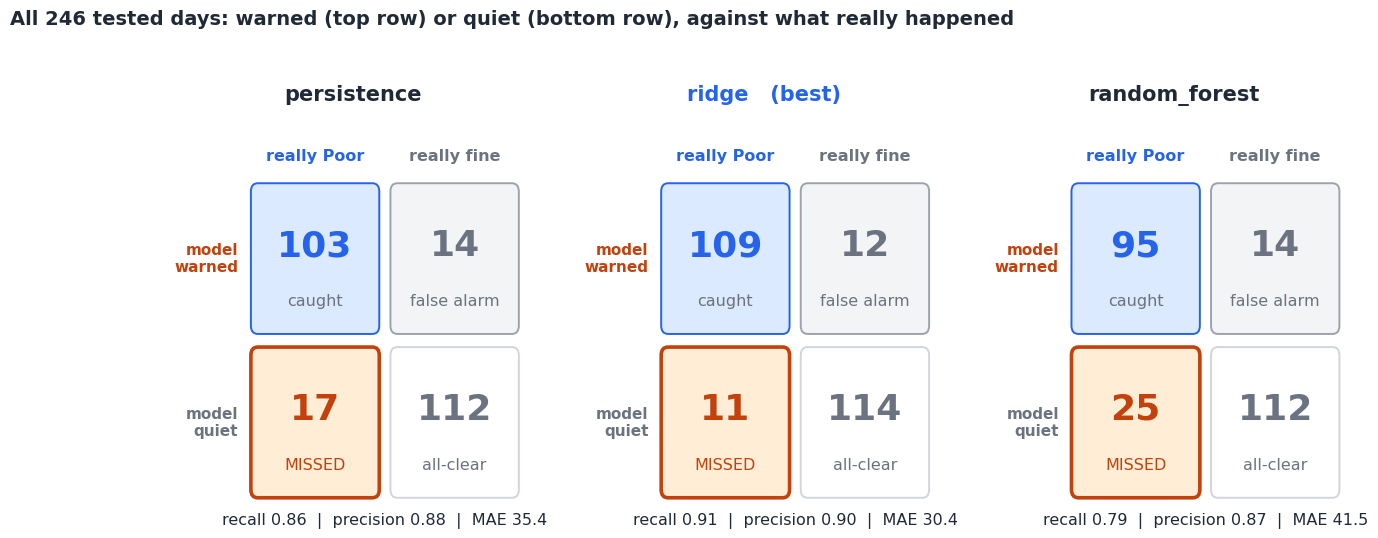

Confusion matrix for the best model (ridge), all 246 days, warning line 91:


,Really Poor,Really fine
Model said Poor,109,12
Model said fine,11,114


In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# The "best" rule, written before looking: lowest overall MAE AND highest overall recall.
best_by_mae = overall_table["mae"].idxmin()
best_by_recall = overall_table["recall"].idxmax()
print(f"lowest overall MAE: {best_by_mae} | highest overall recall: {best_by_recall}")
assert best_by_mae == best_by_recall, "the two disagree: show both and discuss before choosing"
best = best_by_mae

# --- One confusion matrix per model, the best one outlined in blue -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
shade = {"tp": ("#dbeafe", ACCENT), "fp": ("#f3f4f6", "#9ca3af"), "fn": ("#ffedd5", ALERT), "tn": ("white", "#d1d5db")}
place = {"tp": (0, 1), "fp": (1, 1), "fn": (0, 0), "tn": (1, 0)}            # (column, row), top row = warned
label = {"tp": "caught", "fp": "false alarm", "fn": "MISSED", "tn": "all-clear"}
for ax, (name, result) in zip(axes, overall.items()):
    ax.set_xlim(-0.45, 2); ax.set_ylim(0, 2.35); ax.axis("off")
    for box, (col, row) in place.items():
        face, edge = shade[box]
        ax.add_patch(FancyBboxPatch((col + 0.04, row + 0.04), 0.92, 0.92, boxstyle="round,pad=0,rounding_size=0.05",
                                    fc=face, ec=edge, lw=2.6 if box == "fn" else 1.4))
        ax.text(col + 0.5, row + 0.58, str(result[box]), ha="center", va="center", fontsize=26, fontweight="bold",
                color=edge if edge not in ("#d1d5db", "#9ca3af") else MUTED)
        ax.text(col + 0.5, row + 0.24, label[box], ha="center", va="center", fontsize=11.5, color=edge if box == "fn" else MUTED)
    ax.text(0.5, 2.1, "really Poor", ha="center", fontsize=11.5, color=ACCENT, fontweight="bold")
    ax.text(1.5, 2.1, "really fine", ha="center", fontsize=11.5, color=MUTED, fontweight="bold")
    ax.text(-0.05, 1.5, "model\nwarned", ha="right", va="center", fontsize=11, color=ALERT, fontweight="bold")
    ax.text(-0.05, 0.5, "model\nquiet", ha="right", va="center", fontsize=11, color=MUTED, fontweight="bold")
    title = f"{name}" + ("   (best)" if name == best else "")
    ax.set_title(title, fontsize=15, fontweight="bold", color=ACCENT if name == best else INK, pad=14)
    ax.text(1, -0.12, f"recall {result['recall']:.2f}  |  precision {result['precision']:.2f}  |  MAE {result['mae']:.1f}",
            ha="center", fontsize=11.5, color=INK)
fig.suptitle("All 246 tested days: warned (top row) or quiet (bottom row), against what really happened", x=0.01, ha="left",
             fontsize=14, fontweight="bold", color=INK, y=1.1)
plt.show()

print(f"Confusion matrix for the best model ({best}), all 246 days, warning line 91:")
display(confusion_table(overall[best]))

### Read the result

| Overall, 246 days, 120 of them Poor | MAE | Poor days caught | Missed | False alarms | Recall | Precision |
|---|---:|---:|---:|---:|---:|---:|
| **Ridge** | **30.4** | **109** | **11** | **12** | **0.91** | **0.90** |
| Persistence | 35.4 | 103 | 17 | 14 | 0.86 | 0.88 |
| Random forest | 41.5 | 95 | 25 | 14 | 0.79 | 0.87 |

**Ridge is the best model**, by the rule we wrote before running: it has the lowest MAE **and** the highest recall, so there is nothing to argue about. Its confusion matrix is the second table above: 109 caught, 11 missed, 12 false alarms, 114 correct all-clears.

Four things to read carefully:

- **The overall recall is flattered by winter.** November, December and January are 67 days, and every one was Poor. A model only has to say "warn" there. The real test is the months where fine and Poor days mix. In March Ridge caught 8 of 9 Poor days but raised 8 false alarms. In April it caught only 4 of 7.
- **Half of Ridge's misses come from the first exam.** It missed 6 of its 11 Poor days in October, caught 12 of 18, and had never seen smog. After that it missed 5 across the other months (March 1, April 3, May 1).
- **Persistence beat Ridge in October.** It caught 16 of 18, Ridge caught 12. When the smog starts, "tomorrow will be like the afternoon so far" is already high, and that is a strong clue. Ridge's lead comes from February to April, where it follows the fall better (Feb: caught 18 of 18 against persistence's 14).
- **The random forest is the weakest at the start.** It caught only 2 of 18 Poor days in October, the "never forecast above 95" problem we saw in Step 3. It then catches every Poor day from November to February. It also has the biggest error in February (MAE 93.6, against 19.7 for Ridge).

Two smaller points:

- **June to August have no recall.** There were no Poor days, so the table shows a dash. The random forest raised a false alarm in June and one in July, which only shows up in the false-alarm table.
- **This is not comparable with DAF-15.** There, Ridge caught 12 of 17 Poor days (0.71) on one spring-and-summer cut. Here it is 109 of 120 over 11 months. Different days, different method. That is why the log rows will be marked `walk-forward`.

## Before Step 5

Step 4 scored everything: Ridge leads overall, persistence wins October, and the random forest struggles at the start. The overall numbers hide the month-by-month story, which is exactly what Step 5 draws.

Step 5 plots recall per month for the three models, with a gap where a month has no Poor day.

# Step 5 — Recall per month, as a picture

## 🎬 How we got here

Step 4 scored all three models. Ridge won overall: it caught 109 of 120 Poor days. But the same step also showed the overall number hides a lot. Ridge caught 12 of 18 in October and 8 of 9 in March, and the random forest caught only 2 of 18 in October. Those facts are spread over a table of numbers, and a table of numbers is hard to read.

## 😖 The problem

Asha does not care about the average over a year. She cares about **which month her model is dangerous in**. Scanning eleven rows and three columns for that is slow, and it is easy to miss that one model collapses in one month.

```text
table:    2025-10   0.89   0.67   0.11   <- you have to compare these by eye, row after row
picture:  one line per model: a drop is visible at a glance
```

## 💡 The idea

One line per model, recall on the vertical axis, the months running left to right. A line that drops means the model **missed more Poor days that month**.

```text
recall
 1.0 |        ●---●---●---●
     |      /
     |    ●                       a line = one model
     |  /                         a gap in the line = a month with no Poor day
 0.0 |●
     +------------------------------ month
```

Backend analogy: this is the same dashboard panel as "alert catch rate per week". You do not read the average. You look for the week it fell off a cliff.

## 🔍 What this actually is

- **Same numbers as Step 4.** The picture only draws `recall_by_month`. Nothing is recomputed.
- **Gaps are not zeros.** June, July and August have no Poor day, so there is no point and the lines stop. A line that fell to zero would mean "caught none", which is different.
- **A second panel shows the sample size.** Under the recall lines, a bar shows how many Poor days each month had. A point resting on 1 Poor day (May) deserves much less trust than one resting on 29.
- **Shaded winter.** November to January had no fine day at all, so recall is easy there. We shade it so nobody is impressed by a line at 1.00.

### 🤔 Before you run the code

Which month do you expect to be the lowest point of the **Ridge** line? And which model's line do you expect to be at the bottom in October? Then look at the picture.

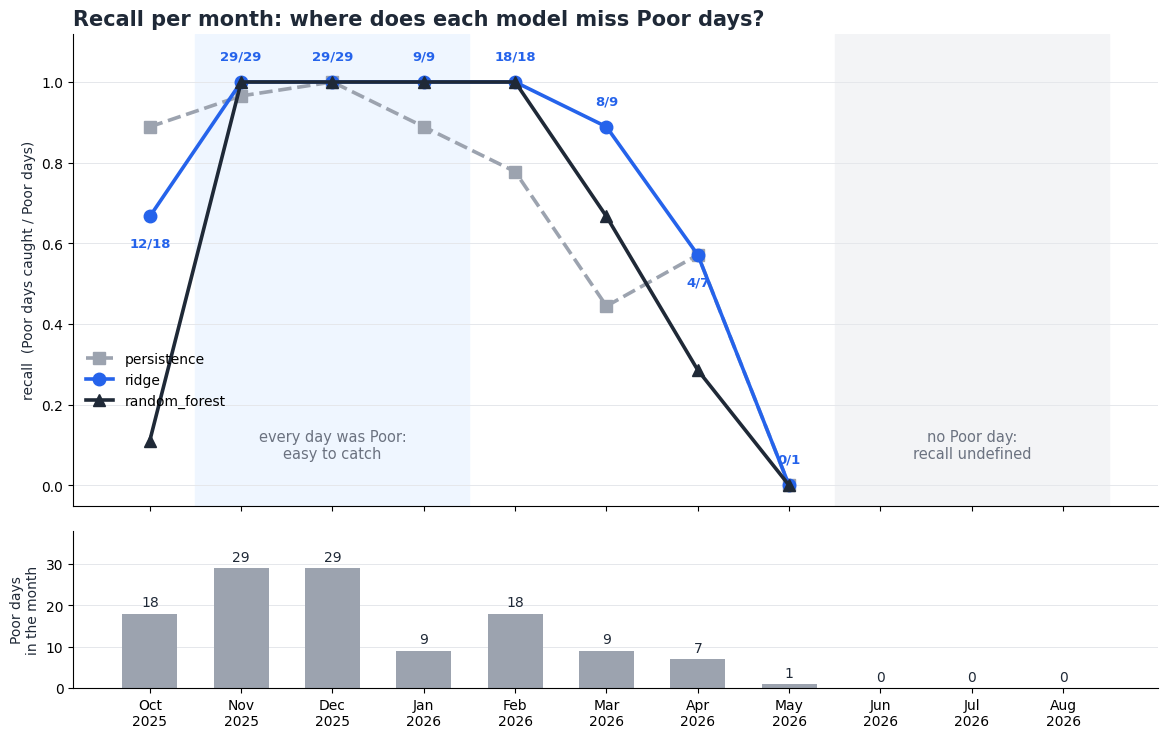

In [17]:
# Continues from Step 4: recall_by_month (n_days, n_poor and one recall column per model), by_month.

# --- 1. Tidy labels and a mask for the months that have no Poor day -----------------------------------
x = np.arange(len(recall_by_month))
month_labels = [pd.Period(m).strftime("%b\n%Y") for m in recall_by_month.index]
all_poor = (recall_by_month["n_days"] == recall_by_month["n_poor"]).to_numpy()     # every day was Poor: Nov, Dec, Jan
no_poor = (recall_by_month["n_poor"] == 0).to_numpy()                              # no Poor day at all: Jun, Jul, Aug
assert all_poor.sum() == 3 and no_poor.sum() == 3                                  # what Step 2 told us

# --- 2. One line per model. NaN means "no Poor day", so matplotlib leaves a gap ---------------------------
look = {"persistence": ("#9ca3af", "--", "s"), "ridge": (ACCENT, "-", "o"), "random_forest": (INK, "-", "^")}

fig, (ax, bars) = plt.subplots(2, 1, figsize=(14, 8.5), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

# Shade the two kinds of month we should read with care.
for mask, color, text in [(all_poor, "#eff6ff", "every day was Poor:\neasy to catch"), (no_poor, "#f3f4f6", "no Poor day:\nrecall undefined")]:
    first, last = np.flatnonzero(mask)[[0, -1]]
    ax.axvspan(first - 0.5, last + 0.5, color=color, zorder=0)
    ax.text((first + last) / 2, 0.06, text, ha="center", va="bottom", fontsize=10.5, color=MUTED)

for name, (color, style, marker) in look.items():
    ax.plot(x, recall_by_month[name], color=color, ls=style, marker=marker, ms=9, lw=2.6, label=name)

# Label every Ridge point with the real counts: Poor days caught / Poor days that month.
ridge_rows = by_month[by_month["model"] == "ridge"].set_index("month").loc[recall_by_month.index]
for xi, (month, row) in zip(x, ridge_rows.iterrows()):
    if row["n_poor"] > 0:
        below = 0.3 < row["recall"] < 0.7                       # keep the label clear of the other lines
        ax.annotate(f"{int(row['tp'])}/{int(row['n_poor'])}", (xi, row["recall"]), textcoords="offset points",
                    xytext=(0, -22 if below else 16), ha="center", fontsize=9.5, color=ACCENT, fontweight="bold")

ax.set_ylim(-0.05, 1.12)
ax.set_ylabel("recall  (Poor days caught / Poor days)", color=INK)
ax.set_title("Recall per month: where does each model miss Poor days?", loc="left", fontsize=15, fontweight="bold", color=INK)
ax.grid(axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 0.18))

# --- 3. The sample size under each month -----------------------------------------------------------------
bars.bar(x, recall_by_month["n_poor"], color="#9ca3af", width=0.6)
for xi, n in zip(x, recall_by_month["n_poor"]):
    bars.text(xi, n + 1, str(int(n)), ha="center", va="bottom", fontsize=10, color=INK)
bars.set_ylabel("Poor days\nin the month", color=INK)
bars.set_ylim(0, 38)
bars.set_xticks(x); bars.set_xticklabels(month_labels)
bars.grid(axis="y", color=GRID, lw=0.7); bars.set_axisbelow(True)
for a in (ax, bars):
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
plt.show()

### What this code does

| Part | What it does |
|---|---|
| `all_poor`, `no_poor` | Two True / False lists picking the months to shade. The `assert` checks that they match Step 2 (3 months each) |
| `ax.plot(x, recall_by_month[name], ...)` | One line per model. A `NaN` value makes the line stop, so there is no line through the empty months |
| `ax.annotate(...)` | Prints `caught/Poor days` above each Ridge point, taken from the Step 4 counts |
| `bars` | A small second chart that shares the month axis and shows how many Poor days each month had |

### Read the picture

| Month | Persistence | Ridge | Random forest | Poor days |
|---|---:|---:|---:|---:|
| Oct 2025 | 0.89 | 0.67 | **0.11** | 18 |
| Nov, Dec | 0.97 / 1.00 | 1.00 | 1.00 | 29 each |
| Jan | 0.89 | 1.00 | 1.00 | 9 |
| Feb | 0.78 | 1.00 | 1.00 | 18 |
| Mar | **0.44** | 0.89 | 0.67 | 9 |
| Apr | 0.57 | 0.57 | **0.29** | 7 |
| May | 0.00 | 0.00 | 0.00 | 1 |
| Jun to Aug | no point | no point | no point | 0 |

What the lines say:

- **October has the widest spread.** The three models are 0.89, 0.67 and 0.11 apart, all on the same 18 Poor days. This is the month with no winter in the training window, and it is where the forest collapses.
- **Winter is flat at 1.00 for Ridge and the forest**, as the shading warns. Persistence slips a little (0.89 in January, 0.78 in February).
- **Spring is where everyone drops.** Ridge goes 0.89 in March and 0.57 in April. Poor days get rarer (9, then 7, then 1), so every miss is a bigger share of the month.
- **Ridge is never the lowest line.** Persistence is lowest in November, January, February and March. The forest is lowest in October and April. In May all three tie. That steadiness is why Ridge wins overall, even though persistence beats it in October.
- **Read the low points with the bars underneath.** May's 0.00 rests on one Poor day. The two drops that matter are October (0.67 on 18 days) and April (0.57 on 7 days).

**One thing for Asha to take away.** Even the best model is weakest at the two edges of the smog season: when it starts (October) and when it fades (April). Those are the evenings when she is most likely to send the children out into Poor air.

## Before Step 6

Step 5 drew the month-by-month recall. Everything so far used the official warning line, 91. Step 6 asks what happens when the line moves: warn at 80, or 70, and catch more Poor days at the price of more false alarms.

Step 6 tries warning lines from 70 to 100 and plots recall and false alarms against the line.

# Step 6 — Moving the warning line

## 🎬 How we got here

Step 5 showed where Ridge misses Poor days: the start of the smog season (October, 12 of 18 caught) and its end (April, 4 of 7). Every number so far used one rule: warn when the forecast is **91 or more**, the official Poor line.

Asha has noticed something. A missed Poor day is far worse than a false alarm. So why wait until the forecast reaches 91? If the model says 85, she could already keep the children in.

## 😖 The problem

Lowering the warning line is easy to do and easy to overdo. Each step down catches a few more Poor days, and it also warns on fine days:

```text
warn at 91   a forecast of 88 on a day that turns out Poor  ->  MISSED
warn at 85   the same forecast of 88                        ->  caught
             but a forecast of 88 on a day that turns out fine  ->  new false alarm
```

How far can she go? At the extreme, "warn at 0" warns every day: every Poor day is caught, so recall is a perfect 1.00. That is also a model that never lets the children out. Recall alone cannot tell a good line from a useless one.

## 💡 The idea

Keep the **truth** fixed at 91, and slide only the **warning line**. For each line from 100 down to 70, score every model with the Step 1 ruler and write down two numbers:

```text
for line in 100, 99, 98, ... 70:
    recall        = Poor days caught / 120 Poor days
    false alarms  = fine days the model warned on          (there are 126 fine days)
```

Then draw both against the line. The picture is the price list: what each extra caught Poor day costs in false alarms.

Backend analogy: this is an alert threshold. Lowering "page me at 90% CPU" to "page me at 70%" catches more real incidents, and it also wakes you for ones that would have fixed themselves. You choose the threshold by looking at how many false pages you can live with.

## 🔍 What this actually is

- **Two lines, as designed in Step 1.** `poor_line = 91` decides what really counts as a Poor day. `warn_at` moves. Our `score_forecasts` already takes both.
- **The forecasts do not change.** Step 3 made them once. Only the yes / no decision made from them changes. Nothing is retrained.
- **A check at 91.** At the official line the sweep must give exactly the Step 4 numbers. If it does not, something is wrong.
- **Two shape checks.** Lowering the line can never reduce recall, and can never reduce false alarms. If either went the wrong way, the notebook stops.
- **"False alarms per month"** is the total divided by the 11 tested months. Most of them fall in the spring months, so the average hides the clusters. We also look month by month.
- **This step does not choose the line.** It prices the options. Choosing is Step 7.

### 🤔 Before you run the code

Ridge caught 109 of 120 Poor days at 91, with 12 false alarms. If Asha lowers the line to 80, how many more Poor days do you expect it to catch, and how many more false alarms? Make a guess for both, then read the table.

In [18]:
# Continues from Steps 3 and 4: forecasts, overall, poor_line, score_forecasts.

# --- 1. Score every model at every warning line from 100 down to 70 ---------------------------------
# `poor_line` stays at 91 (what REALLY counts as Poor). Only `warn_at` moves.
lines = list(range(100, 69, -1))
sweep_rows = []
for name, table_ in forecasts.items():
    for line in lines:
        result = score_forecasts(table_["actual"], table_["predicted"], poor_line=poor_line, warn_at=line)
        sweep_rows.append({"model": name, "line": line, **result})
sweep = pd.DataFrame(sweep_rows)

# --- 2. Safety checks ------------------------------------------------------------------------------------
for name in forecasts:
    mine = sweep[sweep["model"] == name].set_index("line")
    # At the official line, the sweep must reproduce Step 4 exactly.
    for box in ("tp", "fn", "fp", "tn"):
        assert mine.loc[91, box] == overall[name][box], f"{name}: sweep at 91 differs from Step 4"
    # Lowering the line (reading the table top to bottom) can only add caught days and false alarms.
    assert mine["tp"].is_monotonic_increasing and mine["fp"].is_monotonic_increasing
print("at line 91 the sweep matches Step 4; lowering the line never reduces recall or false alarms")

# --- 3. A readable table: Ridge at a few lines, and what each line costs compared with 91 ---------------
n_months = forecasts["ridge"]["month"].nunique()                  # 11 tested months
picked = [100, 95, 91, 85, 80, 75, 70]
ridge_sweep = sweep[(sweep["model"] == "ridge") & sweep["line"].isin(picked)].set_index("line")
at_91 = ridge_sweep.loc[91]
price = pd.DataFrame(
    {
        "recall": ridge_sweep["recall"],
        "caught": ridge_sweep["tp"],
        "missed": ridge_sweep["fn"],
        "false alarms": ridge_sweep["fp"],
        "per month": ridge_sweep["fp"] / n_months,
        "extra caught vs 91": ridge_sweep["tp"] - at_91["tp"],
        "extra false alarms vs 91": ridge_sweep["fp"] - at_91["fp"],
    }
)
print(f"Ridge, 120 Poor days and 126 fine days, over {n_months} tested months")
display(price.round({"recall": 3, "per month": 1}))

at line 91 the sweep matches Step 4; lowering the line never reduces recall or false alarms


Ridge, 120 Poor days and 126 fine days, over 11 tested months


,recall,caught,missed,false alarms,per month,extra caught vs 91,extra false alarms vs 91
line,,,,,,,
100,0.842,101,19,7,0.6,-8,-5
95,0.875,105,15,10,0.9,-4,-2
91,0.908,109,11,12,1.1,0,0
85,0.925,111,9,18,1.6,2,6
80,0.933,112,8,23,2.1,3,11
75,0.958,115,5,31,2.8,6,19
70,0.992,119,1,34,3.1,10,22


### What this code does

| Part | What it does |
|---|---|
| `warn_at=line` | The only thing that changes between rows. `poor_line` stays at 91 |
| `sweep` | One row for each model and each of 31 lines, with recall, the four boxes and the day counts |
| first `assert` | At line 91 the answers must equal Step 4's, because it is the same question |
| `is_monotonic_increasing` | Reading from line 100 down to 70, caught days and false alarms can only go up or stay the same |
| `price` | Ridge at seven lines, with the extra caught days and extra false alarms compared with the official line |

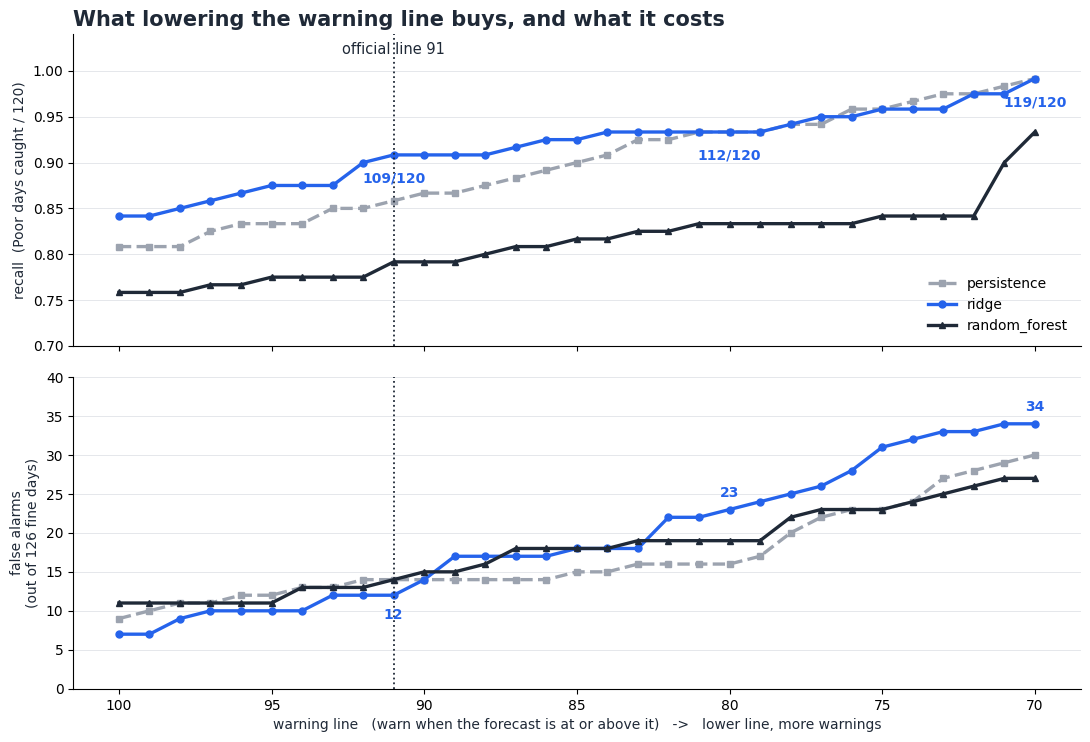

In [19]:
# --- The price list as a picture: recall on top, false alarms below, same horizontal axis -----------------
look = {"persistence": ("#9ca3af", "--", "s"), "ridge": (ACCENT, "-", "o"), "random_forest": (INK, "-", "^")}
fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True, gridspec_kw={"hspace": 0.1})

for name, (color, style, marker) in look.items():
    one = sweep[sweep["model"] == name]
    top.plot(one["line"], one["recall"], color=color, ls=style, marker=marker, ms=5, lw=2.4, label=name)
    bottom.plot(one["line"], one["fp"], color=color, ls=style, marker=marker, ms=5, lw=2.4)

for ax in (top, bottom):
    ax.axvline(91, color=INK, ls=":", lw=1.3)                       # the official line
    ax.grid(axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
top.text(91, 1.015, "official line 91", ha="center", va="bottom", fontsize=10.5, color=INK)

# Label Ridge's price at three lines.
ridge_all = sweep[sweep["model"] == "ridge"].set_index("line")
for line in (91, 80, 70):
    top.annotate(f"{ridge_all.loc[line, 'tp']}/120", (line, ridge_all.loc[line, "recall"]), textcoords="offset points",
                 xytext=(0, -20), ha="center", fontsize=10, color=ACCENT, fontweight="bold")
    bottom.annotate(f"{ridge_all.loc[line, 'fp']}", (line, ridge_all.loc[line, "fp"]), textcoords="offset points",
                    xytext=(0, -17 if line == 91 else 9), ha="center", fontsize=10, color=ACCENT, fontweight="bold")

top.set_ylabel("recall  (Poor days caught / 120)", color=INK)
top.set_ylim(0.7, 1.04)
top.set_title("What lowering the warning line buys, and what it costs", loc="left", fontsize=15, fontweight="bold", color=INK)
top.legend(frameon=False, loc="lower right")
bottom.set_ylabel("false alarms\n(out of 126 fine days)", color=INK)
bottom.set_xlabel("warning line   (warn when the forecast is at or above it)   ->   lower line, more warnings", color=INK)
bottom.set_ylim(0, 40)
bottom.invert_xaxis()                                                # moving right = lowering the line
plt.show()

In [20]:
# --- Where do the extra catches and the extra false alarms happen? Ridge, month by month -----------------
ridge_forecasts = forecasts["ridge"]
compare = {}
for line in (91, 80, 70):
    per_month = {
        month: score_forecasts(part["actual"], part["predicted"], poor_line=poor_line, warn_at=line)
        for month, part in ridge_forecasts.groupby("month")
    }
    compare[f"caught @{line}"] = pd.Series({m: r["tp"] for m, r in per_month.items()})
    compare[f"false alarms @{line}"] = pd.Series({m: r["fp"] for m, r in per_month.items()})
where = pd.concat([days_per_month, pd.DataFrame(compare)], axis=1)
where = where[["n_poor"] + [f"caught @{l}" for l in (91, 80, 70)] + [f"false alarms @{l}" for l in (91, 80, 70)]]
display(where)
assert where["caught @70"].sum() == ridge_all.loc[70, "tp"] and where["false alarms @70"].sum() == ridge_all.loc[70, "fp"]

,n_poor,caught @91,caught @80,caught @70,false alarms @91,false alarms @80,false alarms @70
2025-10,18,12,14,17,0,0,0
2025-11,29,29,29,29,0,0,0
2025-12,29,29,29,29,0,0,0
2026-01,9,9,9,9,0,0,0
2026-02,18,18,18,18,2,2,2
2026-03,9,8,9,9,8,13,18
2026-04,7,4,4,7,2,7,11
2026-05,1,0,0,1,0,1,3
2026-06,0,0,0,0,0,0,0
2026-07,0,0,0,0,0,0,0


### Read the result

**Ridge's price list** (120 Poor days, 126 fine days, 11 tested months):

| Warning line | Poor days caught | Recall | False alarms | Per month | Extra caught vs 91 | Extra false alarms vs 91 |
|---:|---:|---:|---:|---:|---:|---:|
| 100 | 101 | 0.84 | 7 | 0.6 | -8 | -5 |
| 95 | 105 | 0.88 | 10 | 0.9 | -4 | -2 |
| **91** | **109** | **0.91** | **12** | **1.1** | 0 | 0 |
| 85 | 111 | 0.93 | 18 | 1.6 | +2 | +6 |
| 80 | 112 | 0.93 | 23 | 2.1 | +3 | +11 |
| 75 | 115 | 0.96 | 31 | 2.8 | +6 | +19 |
| 70 | 119 | 0.99 | 34 | 3.1 | +10 | +22 |

So lowering the line to 80, the example in the ticket, catches **3 more** Poor days and costs **11 more** false alarms. That is not a bargain: nearly four false alarms for every extra catch.

What the picture and the month table add:

- **The price is not steady.** From 91 to 85: 2 more caught, 6 more false alarms. From 85 to 80: 1 more caught, 5 more false alarms. But from 75 to 70: 4 more caught for only 3 more false alarms. The last step is the cheapest.
- **The cheap catches come from October.** Moving from 91 to 70, Ridge catches 5 more Poor days in October (12 to 17) and **adds no false alarm in October at all**: Ridge's forecasts on October's 11 fine days all stay below 70.
- **The expensive false alarms are all in spring.** At line 70 the 34 false alarms sit in February (2), March (18), April (11) and May (3). Lowering the line mostly means more cancelled outdoor days in March and April, when the air is borderline.
- **The models agree.** Persistence and Ridge both reach recall 0.99 at line 70 (119 of 120), with 30 and 34 false alarms. The random forest never gets above 112 caught at line 70, so lowering the line cannot fix its October problem.
- **The averages hide the clusters.** "3.1 false alarms per month" at line 70 is really 0 in most months and 18 in March.

**The trap, seen in numbers.** Going all the way down gives recall 1.00 and 126 false alarms: every fine day cancelled. Line 70 sits much closer to that end than line 91 does.

## Before Step 7

Step 6 priced every line from 100 to 70. Nothing is decided yet. Step 7 is Asha's call, and it asks one question the data cannot answer alone: how many cancelled outdoor days is one extra caught Poor day worth?

Step 7 reads the price list, decides whether to move the line, and writes it down as decision D-007 if we do.

# Step 7 — Should Asha move the line?

## 🎬 How we got here

Step 6 priced every warning line from 100 to 70. For Ridge, lowering the line from 91 to 80 caught 3 more Poor days and cost 11 more false alarms. Lowering it all the way to 70 caught 10 more and cost 22 more. The table is complete, but a table does not decide anything.

## 😖 The problem

Nothing in the data says which line is right. The answer depends on a question about Asha, not about the model:

> **How many cancelled outdoor days would Asha accept to avoid one missed Poor day?**

If a missed Poor day is only a little worse than a false alarm, the official line is already fine. If it is much worse, the line should drop. Two people with the same table can honestly pick different lines.

## 💡 The idea

Turn her answer into one number, **k**:

```text
k = false alarms Asha would accept to avoid ONE missed Poor day

cost of a line = false alarms + k x missed Poor days
```

For each k, the best line is the one with the lowest cost. Then Asha does not have to read 31 rows. She only has to say which k sounds like her.

```text
k = 1     "a missed day is as bad as one cancelled day"              (she does not mind missing)
k = 3     "I would cancel three outdoor days to avoid one miss"
k = 10    "I would cancel ten days to avoid one miss"
```

Backend analogy: this is how an on-call team sets an alert threshold. Nobody picks "70%" for CPU on its own. They decide how many false pages are worth one real outage caught, and the threshold follows from that.

## 🔍 What this actually is

- **Wider than the ticket's range.** The ticket asks for 70 to 100. In Step 6 the cheapest catches sat at the low edge of that range, so a decision made only up to 70 could be an artefact of where we stopped. We score 100 down to 60 here, so the lowest point of each curve is inside the range.
- **Ties go to the higher line.** If two lines have the same cost, the one that warns less wins.
- **The choice of k is the human part.** The code only turns each k into a line.
- **Three honest limits, read before the table:**
  1. We pick the line on the same 246 days that we report. That is a little optimistic. The truth would be tested on days not used to pick the line.
  2. A lot of the cheap catches come from October, when the model had never seen smoke. The live service will have a winter behind it next year, so those catches may shrink.
  3. With one winter in the data, any exact number such as 68 against 70 rests on a single day. Treat the answer as a round number, not a precise optimum.

### 🤔 Before you run the code

Think of Asha. If she sends 600 children out into Poor air, how many cancelled outdoor days would she accept to avoid that? Pick your own k, then see which line it gives.

In [21]:
# Continues from Steps 4 and 6: forecasts, overall, poor_line, score_forecasts.

# --- 1. Ridge at every warning line from 100 down to 60 -----------------------------------------------------
ridge_forecasts = forecasts["ridge"]
wide_lines = list(range(100, 59, -1))
wide = pd.DataFrame(
    [
        {"line": line, **score_forecasts(ridge_forecasts["actual"], ridge_forecasts["predicted"], poor_line=poor_line, warn_at=line)}
        for line in wide_lines
    ]
).set_index("line")
assert wide.loc[91, "fp"] == overall["ridge"]["fp"] and wide.loc[91, "fn"] == overall["ridge"]["fn"]   # same as Step 4

# --- 2. The cost of each line, for several values of k -----------------------------------------------------
# cost = false alarms + k x missed Poor days.  Lower is better.
ks = [0.5, 1, 2, 3, 5, 10]
costs = pd.DataFrame({k: wide["fp"] + k * wide["fn"] for k in ks})

# --- 3. For each k: which line has the lowest cost? ----------------------------------------------------------
rows = []
for k in ks:
    best_line = costs[k].idxmin()                       # first minimum = the highest line if there is a tie
    rows.append(
        {
            "k": k,
            "best line": best_line,
            "caught": int(wide.loc[best_line, "tp"]),
            "missed": int(wide.loc[best_line, "fn"]),
            "false alarms": int(wide.loc[best_line, "fp"]),
            "extra caught vs 91": int(wide.loc[best_line, "tp"] - wide.loc[91, "tp"]),
            "extra false alarms vs 91": int(wide.loc[best_line, "fp"] - wide.loc[91, "fp"]),
        }
    )
best_per_k = pd.DataFrame(rows).set_index("k")
display(best_per_k)

# Where does the very lowest line stop being worth it? (the cost at 91 is the reference)
print("Lines below 68 add false alarms and no more catches:",
      wide.loc[[68, 65, 60], ["tp", "fn", "fp"]].to_dict("index"))

,best line,caught,missed,false alarms,extra caught vs 91,extra false alarms vs 91
k,,,,,,
0.5,100,101,19,7,-8,-5
1.0,91,109,11,12,0,0
2.0,91,109,11,12,0,0
3.0,68,120,0,34,11,22
5.0,68,120,0,34,11,22
10.0,68,120,0,34,11,22


Lines below 68 add false alarms and no more catches: {68: {'tp': 120, 'fn': 0, 'fp': 34}, 65: {'tp': 120, 'fn': 0, 'fp': 41}, 60: {'tp': 120, 'fn': 0, 'fp': 55}}


### What this code does

| Part | What it does |
|---|---|
| `wide` | Ridge scored at 41 lines, 100 down to 60, with the Step 1 ruler |
| `costs` | One column per k. `fp + k * fn` is the cost of that line for that k |
| `costs[k].idxmin()` | The line with the lowest cost for this k. If there is a tie, `idxmin` returns the first, which is the highest line |
| `best_per_k` | The answer table: one row per k, with what that line catches and what it costs compared with the official 91 |

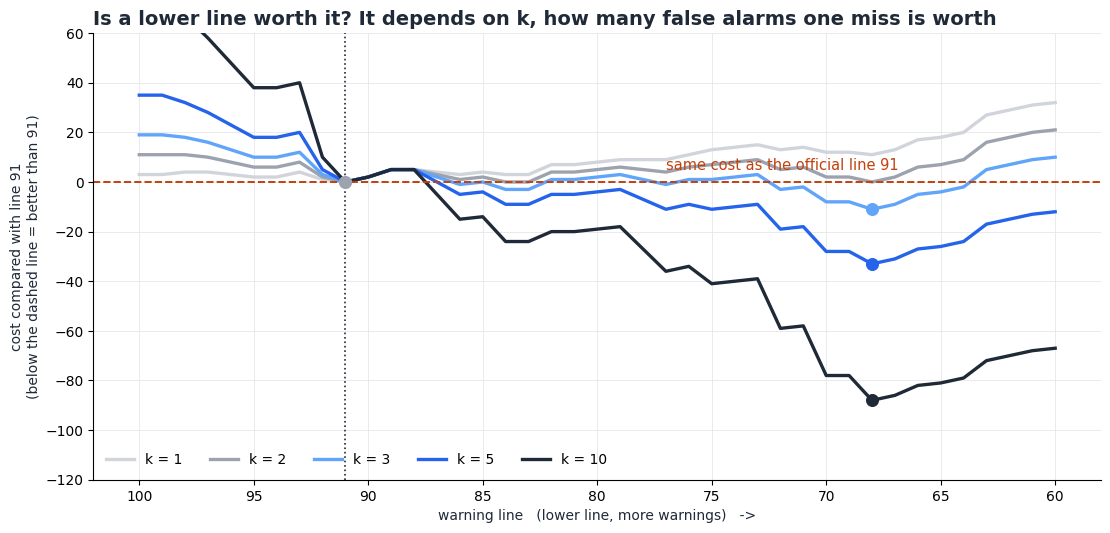

In [22]:
# --- The same thing as a picture: cost of each line, compared with the official line 91 -------------------
fig, ax = plt.subplots(figsize=(13, 5.8))
shades = {1: "#d1d5db", 2: "#9ca3af", 3: "#60a5fa", 5: ACCENT, 10: INK}
for k, color in shades.items():
    ax.plot(wide.index, costs[k] - costs.loc[91, k], color=color, lw=2.4, label=f"k = {k}")
    low = costs[k].idxmin()
    ax.scatter([low], [costs.loc[low, k] - costs.loc[91, k]], color=color, s=70, zorder=3)

ax.axhline(0, color=ALERT, ls="--", lw=1.4)
ax.text(77, 5, "same cost as the official line 91", color=ALERT, fontsize=10.5, ha="left")
ax.axvline(91, color=INK, ls=":", lw=1.2)
ax.invert_xaxis()                                            # moving right = lowering the line
ax.set_ylim(-120, 60)
ax.set_xlabel("warning line   (lower line, more warnings)   ->", color=INK)
ax.set_ylabel("cost compared with line 91\n(below the dashed line = better than 91)", color=INK)
ax.set_title("Is a lower line worth it? It depends on k, how many false alarms one miss is worth", loc="left", fontsize=14, fontweight="bold", color=INK)
ax.grid(color=GRID, lw=0.6); ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="lower left", ncol=5)
plt.show()

### Read the result

| If one missed Poor day is worth this many false alarms (k) | Best line | Caught | Missed | False alarms | vs line 91 |
|---:|---:|---:|---:|---:|---|
| 0.5 | 100 | 101 | 19 | 7 | 8 fewer caught, 5 fewer false alarms |
| 1 | 91 | 109 | 11 | 12 | the official line |
| 2 | 91 | 109 | 11 | 12 | the official line (68 is exactly tied) |
| 3, 5 or 10 | **68** | **120** | **0** | **34** | **11 more caught, 22 more false alarms** |

**The answer has a clean break at k = 2.** Moving from 91 to 68 buys 11 more caught Poor days for 22 more false alarms, which is exactly 2 false alarms per extra catch. So:

- If Asha would accept **fewer than 2** cancelled days to avoid a missed Poor day, keep 91.
- If she would accept **more than 2**, lower the line, to about 70.
- There is **no case for an in-between line** such as 80. I also checked every k from 0.1 to 20 in small steps: the winner is always 91, 68, or (for k below 0.6) 99 to 100. In-between lines only tie, at exactly k = 2, and never win. Line 80 is never the winner.

The picture shows the same thing. For k = 3, 5 and 10 the curves fall below the dashed line and bottom out at 68. Below 68, the table above shows the extra false alarms buy no more catches: line 65 has 41 false alarms and 60 has 55, with the same 120 caught.

What lowering the line to about 70 would mean in Asha's terms, from Step 6's month table:

- About **10 fewer missed Poor days** over the year, 5 of them in October.
- About **22 more cancelled outdoor days** over the year, all between February and May, mostly March and April. That is roughly 2 extra cancelled days a month in spring.

Read the three limits from the start of this step again before choosing: the line is picked on the same days we score, October's cheap catches may shrink once the live model has a winter behind it, and 68 against 70 is one day. The choice is Asha's.

## The decision

**Keep the warning line at 91. The line does not move, so there is no D-007.**

**Asha's answer to the k question:** she would not cancel more than 2 outdoor days to avoid one missed Poor day. At k = 2 or less, the official line is the best line, or tied for best (at k = 2, line 68 ties with it exactly).

**Why keeping it is the safer choice on this evidence:**

- The case for lowering the line rests on 22 extra false alarms against 10 or 11 extra catches. That is a good trade only if she values a miss at more than 2 cancelled days, and her answer is no.
- The cheap catches are in October, when the model had never seen smoke. The live service will have a winter behind it, so most of those catches may not repeat. The 22 extra false alarms in spring probably will.
- The line would be picked on the same 246 days we report, and the winning line (68) depends on a single day.
- 91 is the official CPCB line. Keeping it means Asha can explain every warning with the published table (D-001).

**What would make us change our minds:**

- A second winter of data, scoring the live model with a winter in its training window. If October recall is still low, we test lowering the line again.
- A change in Asha's answer. If a missed Poor day starts to cost more than 2 cancelled days, the break-even moves, and the line should move with it.
- A model that predicts October better. That makes the cheap catches cheaper still.

## Before Step 8

Step 7 reduced the decision to one question about k. Step 8 writes the evidence down: the walk-forward rows in `reports/experiments.csv`, marked `walk-forward`, with the line kept at 91 recorded in their notes. No D-007, because the line did not move.

# Step 8 — Write the evidence down

## 🎬 How we got here

Steps 1 to 7 produced the results: three models scored on 246 days across 11 monthly exams, Ridge best, and the warning line kept at 91. They exist only inside this notebook. Close it, and the numbers are gone.

## 😖 The problem

DAF-17 will tune the models and DAF-18 will make the final test. Both need to know what DAF-16 found, in one place, in the same format as every earlier experiment. There is also a risk of mixing things up:

```text
DAF-15 rows   one cut date, 130 test days, spring and summer
DAF-16 rows   11 monthly exams, 246 test days, a whole winter

same column names, DIFFERENT exam
```

A reader who ranks the two kinds of row against each other will compare scores from different exams. The rows must say which kind they are.

## 💡 The idea

Add one row per model to `reports/experiments.csv`, the same file used since DAF-06. Every row is **marked `walk-forward`** in its notes, with enough detail to understand it later: how many exams, how many days, which line, and the four boxes.

```text
overall (Step 4) ──► 3 rows in the experiment log, each marked "walk-forward"
                              |
                              v
        a later ticket can find them, and knows not to rank them against the single-cut rows
```

Backend analogy: this is the benchmark history. A new entry has to say which benchmark it ran on, or the next person compares apples with oranges.

## 🔍 What this actually is

- **The row holds the overall MAE and recall**, like every earlier row, from all 246 days. The caught, missed and false-alarm counts and the precision go in `notes`.
- **The warning line is written in the notes** (91), because Step 7 decided to keep it. If the line ever moves, the rows say which line they used.
- **Safe to re-run.** Any earlier DAF-16 row is removed before the new ones are added, so running twice does not duplicate.
- **Nothing else is touched.** A check confirms that every row from other tickets is unchanged.

### 🤔 Before you run the code

After this step, the log will hold both kinds of row. Which of the three models will have the highest `recall_poor` in the log, across **all** rows, and is that a fair claim? Think about it, then read the result.

In [23]:
# Continues from Steps 2, 4 and 7: overall (scores on all 246 days), feature_names, walk_start, forecasts.

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]

# What each model is, in the words a reader needs later.
model_notes = {
    "persistence": "persistence, no fitting, forecast = pm25_until_17",
    "ridge": "StandardScaler+Ridge(alpha=1.0, solver=lsqr), refitted each month",
    "random_forest": "RandomForestRegressor defaults, random_state=0, refitted each month",
}

n_exams = forecasts["ridge"]["month"].nunique()
new_rows = []
for name, result in overall.items():
    new_rows.append(
        {
            "ticket": "DAF-16",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": f"daf16_{name}_walk_forward",
            "features": ", ".join(feature_names),
            "mae": round(result["mae"], 3),
            "recall_poor": round(result["recall"], 3),
            "notes": (
                f"walk-forward: expanding window, {n_exams} monthly exams from {walk_start.date()}, "
                f"{result['n_days']} test days ({result['n_poor']} Poor); {model_notes[name]}; "
                f"warning line 91 (kept, no D-007); caught {result['tp']} of {result['n_poor']}, "
                f"missed {result['fn']}, false alarms {result['fp']}, precision {result['precision']:.3f}; "
                "not comparable with single-cut rows"
            ),
        }
    )
new_rows = pd.DataFrame(new_rows, columns=log_columns)

# --- Write them, safe to re-run -----------------------------------------------------------------------
experiment_log = pd.read_csv(log_path)
other_rows = experiment_log.loc[~experiment_log["model"].isin(new_rows["model"])].reset_index(drop=True)
experiment_log = pd.concat([other_rows, new_rows], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote {len(new_rows)} DAF-16 rows to {log_path}")

# --- Safety checks: read the file back and confirm what the ticket asks for ------------------------------
saved = pd.read_csv(log_path)
daf16 = saved.loc[saved["ticket"] == "DAF-16"]
assert len(daf16) == 3, "expected exactly three DAF-16 rows"
assert daf16["notes"].str.contains("walk-forward").all(), "every row must be marked walk-forward"
assert saved.loc[saved["ticket"] != "DAF-16"].reset_index(drop=True).equals(other_rows), "rows from other tickets changed"
for name, result in overall.items():       # the saved numbers are the Step 4 numbers
    row = daf16.set_index("model").loc[f"daf16_{name}_walk_forward"]
    assert row["mae"] == round(result["mae"], 3) and row["recall_poor"] == round(result["recall"], 3)
print("3 rows, all marked walk-forward, other tickets untouched, numbers match Step 4")

display(daf16[["model", "mae", "recall_poor"]].set_index("model"))
print("The full note for the best model:")
print(daf16.set_index("model").loc["daf16_ridge_walk_forward", "notes"])

Wrote 3 DAF-16 rows to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv
3 rows, all marked walk-forward, other tickets untouched, numbers match Step 4


,mae,recall_poor
model,,
daf16_persistence_walk_forward,35.352,0.858
daf16_ridge_walk_forward,30.379,0.908
daf16_random_forest_walk_forward,41.485,0.792


The full note for the best model:
walk-forward: expanding window, 11 monthly exams from 2025-10-01, 246 test days (120 Poor); StandardScaler+Ridge(alpha=1.0, solver=lsqr), refitted each month; warning line 91 (kept, no D-007); caught 109 of 120, missed 11, false alarms 12, precision 0.901; not comparable with single-cut rows


### What this code does

| Part | What it does |
|---|---|
| `model_notes` | One short description per model, so the row explains itself in a month |
| `new_rows` | One row per model: overall MAE and recall in their columns, and the counts, the line and the word `walk-forward` in `notes` |
| `other_rows` + `pd.concat` | Takes the old log without any earlier DAF-16 row, then adds the new rows. Re-running replaces, never duplicates |
| the `assert` block | Reads the file back and stops the notebook if there are not exactly 3 DAF-16 rows, if one is not marked `walk-forward`, if another ticket's rows changed, or if a saved number differs from Step 4 |

### Read the result

Three rows were added to `reports/experiments.csv`, and nothing else in the file changed.

| Model in the log | MAE | `recall_poor` |
|---|---:|---:|
| `daf16_ridge_walk_forward` | 30.379 | 0.908 |
| `daf16_persistence_walk_forward` | 35.352 | 0.858 |
| `daf16_random_forest_walk_forward` | 41.485 | 0.792 |

**Is it fair to say these have the highest recall in the log?** Not really. Their recall (0.79 to 0.91) is higher than every earlier row (the best was 0.706), but the earlier rows were scored on 17 Poor days in spring and summer. These were scored on 120 Poor days, 67 of them in winter months where every day is Poor. The MAE has the same problem: these numbers are larger because winter has bigger swings, not because the models got worse. That is why every note says `walk-forward` and `not comparable with single-cut rows`.

### The ticket's acceptance criteria

| Criterion | Where it is met |
|---|---|
| Confusion matrix shown for the best model on the walk-forward results | Step 4: Ridge, 109 caught, 11 missed, 12 false alarms, 114 correct all-clears |
| Walk-forward covers the winter, each step trained only on earlier data | Step 3: October to August, an `assert` on every split, and the scramble test where changing 2026 left the Oct to Dec forecasts identical |
| Per-month MAE and recall for all three models | Step 4: the MAE and recall tables |
| Threshold plot, and a decision about the line written down | Steps 6 and 7: the sweep from 100 to 70 (extended to 60), and "keep 91" |
| Experiment-log rows marked `walk-forward` | This step: three rows, checked by the `assert` block |

### Explain-back: the numbers you will need

The ticket has three questions. The answers are yours to write, because they are the evidence for your skills record. These are the numbers from this notebook to use:

1. **Why is a missed Poor day worse than a false alarm, in Asha's terms?** Day 3 of the Step 1 example: a forecast of 90 against a real 95 is only 5 off, yet 600 children were outside in bad air. A false alarm of 35 off costs one cancelled outdoor day.
2. **What does walk-forward tell you that one cut date cannot?** In DAF-15 the test period was spring and summer, 17 Poor days. Walk-forward showed that the random forest caught only 2 of 18 Poor days in October (recall 0.11), that persistence beat Ridge that month (16 of 18 against 12), and that every model gets weaker in April. A single cut date could not show any of that.
3. **If you lowered the warning line, what did it cost in false alarms per month?** Line 80: 11 more false alarms over 11 months, about 1 a month, for 3 more caught days. Line 70: 22 more, about 2 a month, for 10 more caught days, all between February and May.

## Before the Recap

All eight steps are done. The recap puts the whole notebook on two pictures.

# Recap — DAF-16 in one picture

Eight steps, one answer. Read this last, or come back to it in a month.

```text
Score -> Start date -> Loop -> Run -> Plot -> Move the line -> Decide -> Log
(Step 1)   (Step 2)   (Step 3) (Step 4) (Step 5)  (Step 6)    (Step 7)  (Step 8)
```

**How to read the pictures**

- **The cards** follow the notebook in order. Each one says what the step did and one number that came out of it.
- **First picture, left chart:** what each model did to the 246 tested days: Poor days caught, Poor days missed, and false alarms.
- **First picture, right chart:** Ridge's price list. Each dot is a warning line. Moving right means more false alarms, moving up means more Poor days caught.
- **Second picture, left chart:** the three experiment-log rows, read back from `reports/experiments.csv`.
- **Second picture, right chart:** the months in which Ridge's mistakes happen.

Every number is read from the earlier cells or from the saved log, so run the notebook from the top.

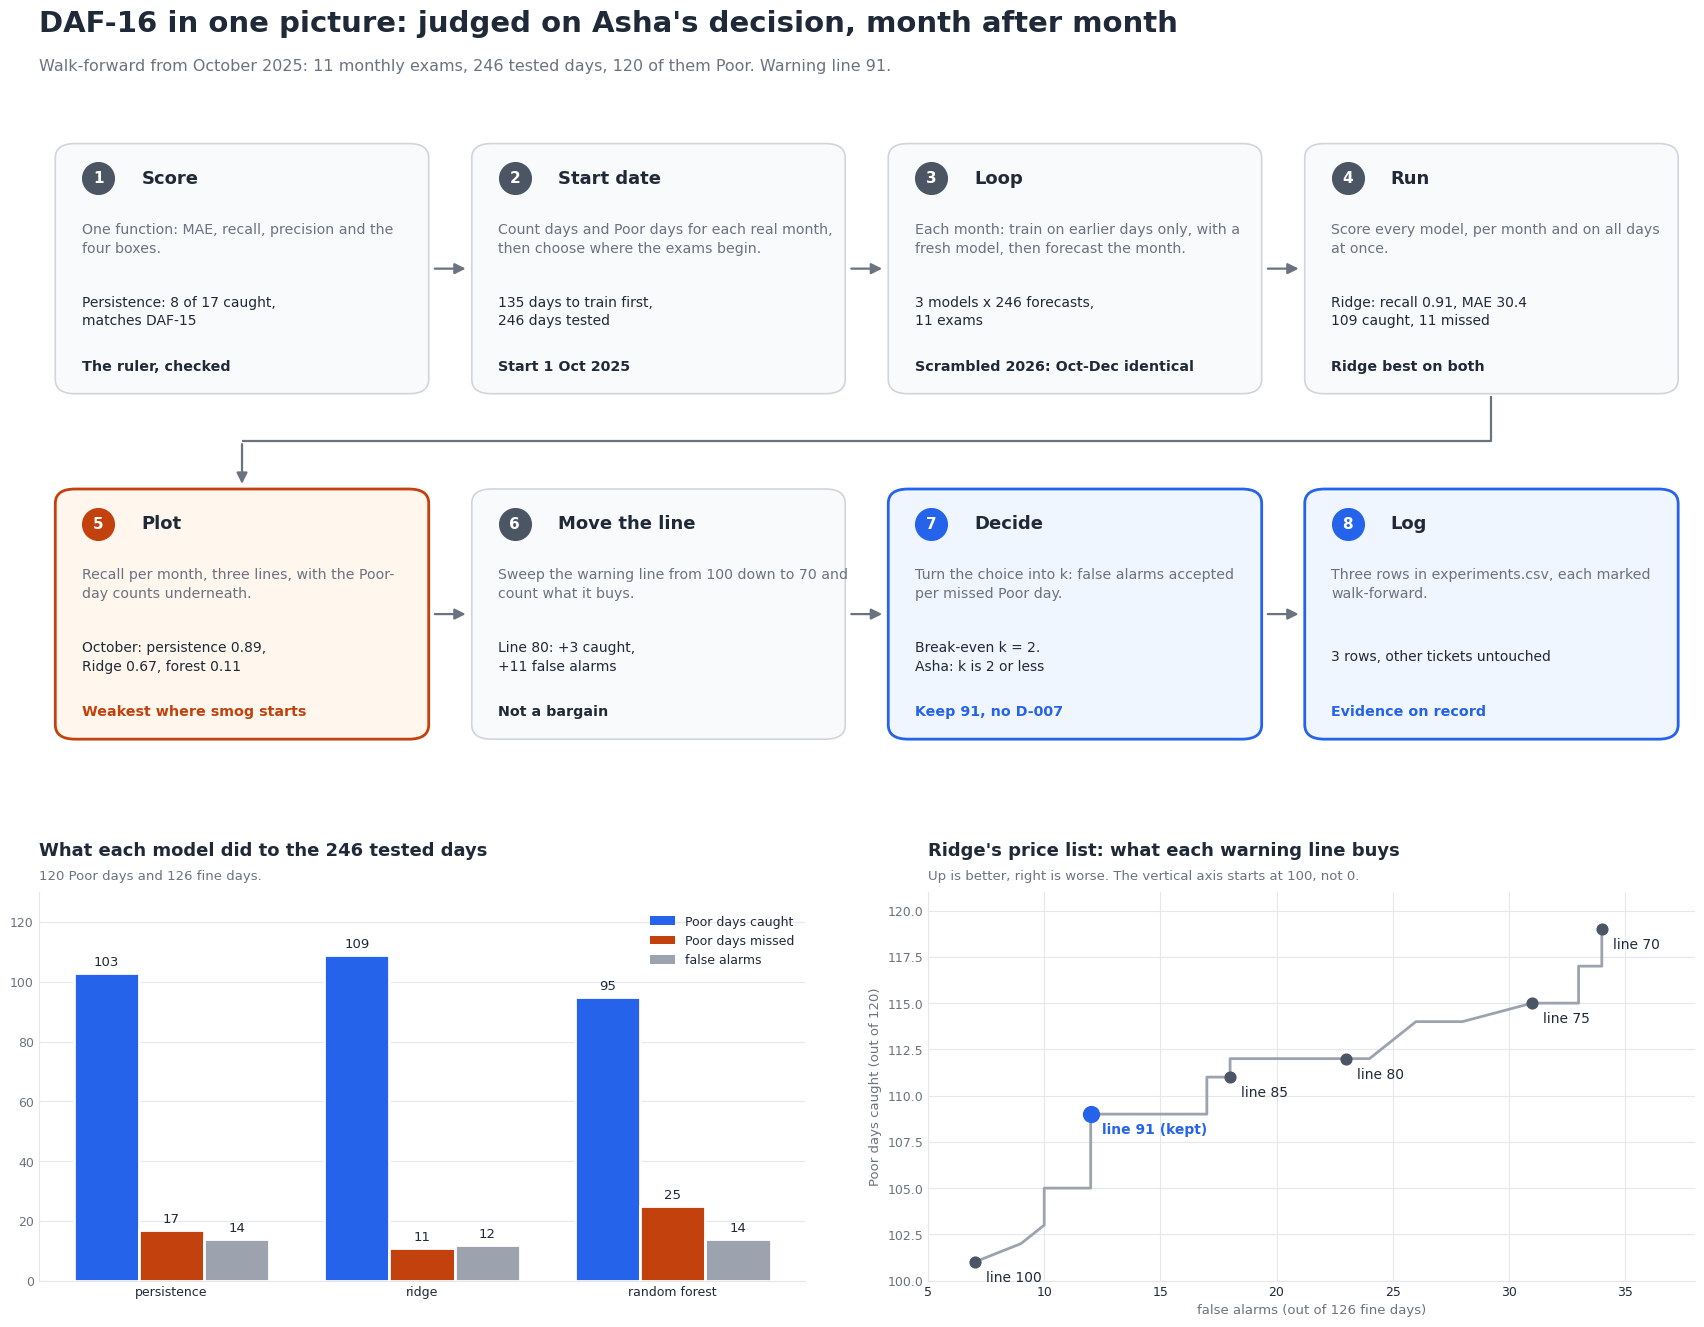

In [24]:
import matplotlib.pyplot as plt

import recap_style as rs

# Continues from Steps 1 to 8. Nothing is typed in by hand: every number comes from an earlier variable.
ridge_row = overall["ridge"]
oct_recall = recall_by_month.loc["2025-10"]
break_even = (wide.loc[68, "fp"] - wide.loc[91, "fp"]) / (wide.loc[68, "tp"] - wide.loc[91, "tp"])

cards = [
    dict(badge="1", title="Score", adds="One function: MAE, recall, precision and the four boxes.",
         numbers=f"Persistence: {persistence['tp']} of {persistence['n_poor']} caught,\nmatches DAF-15", verdict="The ruler, checked"),
    dict(badge="2", title="Start date", adds="Count days and Poor days for each real month, then choose where the exams begin.",
         numbers=f"{len(first_train)} days to train first,\n{len(tested)} days tested", verdict="Start 1 Oct 2025"),
    dict(badge="3", title="Loop", adds="Each month: train on earlier days only, with a fresh model, then forecast the month.",
         numbers=f"3 models x {len(forecasts['ridge'])} forecasts,\n{n_exams} exams", verdict="Scrambled 2026: Oct-Dec identical"),
    dict(badge="4", title="Run", adds="Score every model, per month and on all days at once.",
         numbers=f"Ridge: recall {ridge_row['recall']:.2f}, MAE {ridge_row['mae']:.1f}\n{ridge_row['tp']} caught, {ridge_row['fn']} missed", verdict="Ridge best on both"),
    dict(badge="5", title="Plot", adds="Recall per month, three lines, with the Poor-day counts underneath.",
         numbers=f"October: persistence {oct_recall['persistence']:.2f},\nRidge {oct_recall['ridge']:.2f}, forest {oct_recall['random_forest']:.2f}", verdict="Weakest where smog starts", kind="problem"),
    dict(badge="6", title="Move the line", adds="Sweep the warning line from 100 down to 70 and count what it buys.",
         numbers=f"Line 80: +{price.loc[80, 'extra caught vs 91']} caught,\n+{price.loc[80, 'extra false alarms vs 91']} false alarms", verdict="Not a bargain"),
    dict(badge="7", title="Decide", adds="Turn the choice into k: false alarms accepted per missed Poor day.",
         numbers=f"Break-even k = {break_even:.0f}.\nAsha: k is 2 or less", verdict="Keep 91, no D-007", kind="final"),
    dict(badge="8", title="Log", adds="Three rows in experiments.csv, each marked walk-forward.",
         numbers=f"{len(daf16)} rows, other tickets untouched", verdict="Evidence on record", kind="final"),
]

flow_h = rs.flow_size(len(cards), 4)
fig = plt.figure(figsize=(rs.FIG_W, flow_h + 5.4), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[flow_h, 5.4], hspace=0.28, wspace=0.16, left=0.05, right=0.97, top=0.9, bottom=0.08)
rs.header(fig, "DAF-16 in one picture: judged on Asha's decision, month after month",
          f"Walk-forward from October 2025: {n_exams} monthly exams, {ridge_row['n_days']} tested days, {ridge_row['n_poor']} of them Poor. Warning line {poor_line}.")
rs.draw_cards(fig.add_subplot(grid[0, :]), cards, cols=4)

# Left: what each model did to the 246 days
left = fig.add_subplot(grid[1, 0])
names = list(overall)
positions = range(len(names)); width = 0.26
series = [("caught", "tp", rs.ACCENT), ("missed", "fn", rs.ALERT), ("false alarms", "fp", rs.BAR)]
for offset, (label, key, color) in zip((-width, 0, width), series):
    bars = left.bar([p + offset for p in positions], [overall[n][key] for n in names], width, color=color, edgecolor="white", linewidth=2)
    rs.label_bars(left, bars)
left.set_xticks(list(positions), [n.replace("_", " ") for n in names])
left.set_ylim(0, 130)
rs.legend(left, [("Poor days caught", rs.ACCENT, "bar"), ("Poor days missed", rs.ALERT, "bar"), ("false alarms", rs.BAR, "bar")], loc="upper right", anchor=(1, 0.97))
rs.style_axis(left, "What each model did to the 246 tested days", f"{ridge_row['n_poor']} Poor days and {ridge_row['tn'] + ridge_row['fp']} fine days.")

# Right: Ridge's price list
right = fig.add_subplot(grid[1, 1])
curve = ridge_all.loc[100:70]
right.plot(curve["fp"], curve["tp"], color=rs.BAR, lw=2, zorder=1)
for line in (100, 91, 85, 80, 75, 70):
    keep = line == 91
    right.scatter([ridge_all.loc[line, "fp"]], [ridge_all.loc[line, "tp"]], s=130 if keep else 60, color=rs.ACCENT if keep else rs.BASE_BAR, zorder=3)
    right.annotate(f"line {line}" + (" (kept)" if keep else ""), (ridge_all.loc[line, "fp"], ridge_all.loc[line, "tp"]), textcoords="offset points",
                   xytext=(8, -14), fontsize=10, color=rs.ACCENT if keep else rs.INK, fontweight="bold" if keep else "normal")
right.set_xlabel("false alarms (out of 126 fine days)", fontsize=9.5, color=rs.MUTED)
right.set_ylabel("Poor days caught (out of 120)", fontsize=9.5, color=rs.MUTED)
right.set_xlim(5, 38)
right.set_ylim(100, 121)                                   # zoomed: the axis starts at 100, not 0
rs.style_axis(right, "Ridge's price list: what each warning line buys", "Up is better, right is worse. The vertical axis starts at 100, not 0.", grid_axis="both")
fig.savefig("figures/16_recap.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

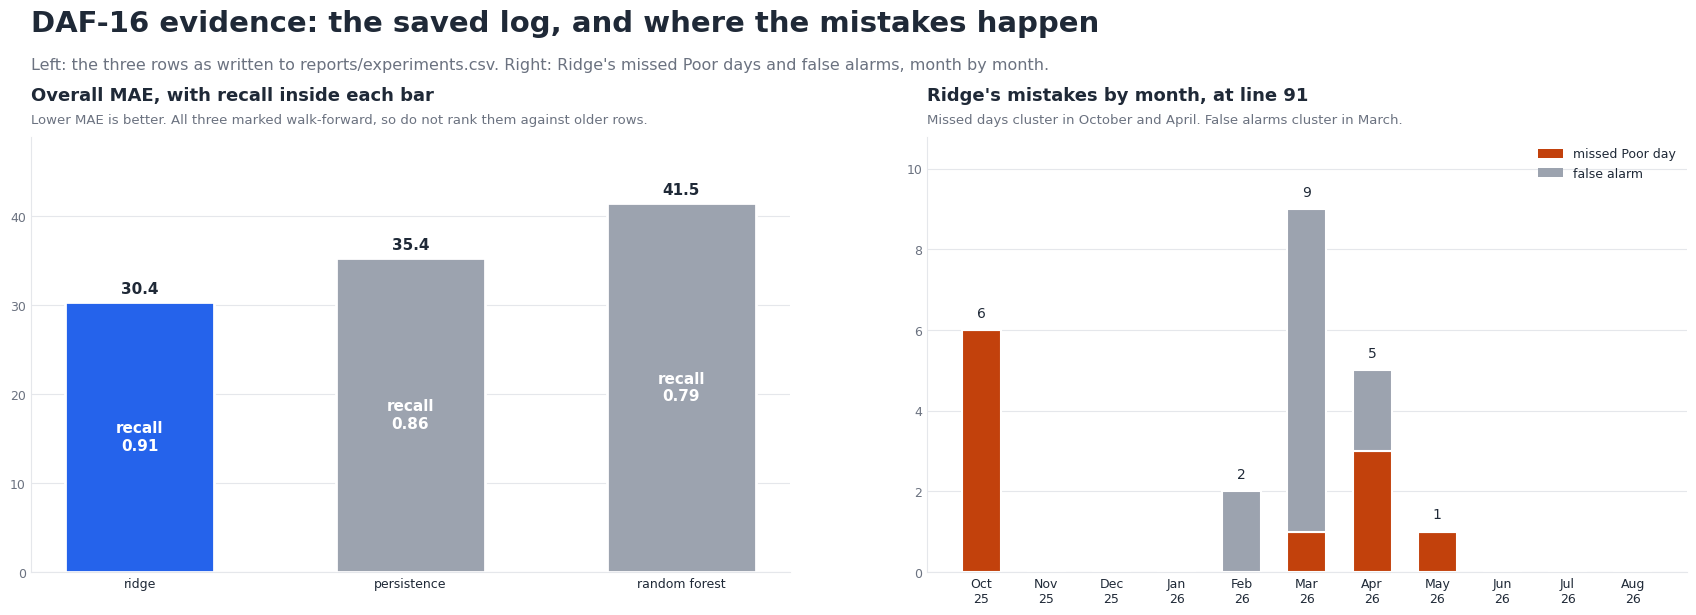

In [25]:
# The evidence figure: the saved log rows, and where Ridge's mistakes happen.
root = rs.find_project_root()
saved_log = pd.read_csv(root / "reports/experiments.csv")
daf16_rows = saved_log.loc[saved_log["ticket"] == "DAF-16"].copy()
daf16_rows["label"] = daf16_rows["model"].str.replace("daf16_", "").str.replace("_walk_forward", "").str.replace("_", " ")
daf16_rows = daf16_rows.sort_values("mae")
assert len(daf16_rows) == 3 and daf16_rows["notes"].str.contains("walk-forward").all()

fig = plt.figure(figsize=(rs.FIG_W, 6.6), facecolor="white")
grid = fig.add_gridspec(1, 2, wspace=0.18, left=0.05, right=0.97, top=0.78, bottom=0.12)
rs.header(fig, "DAF-16 evidence: the saved log, and where the mistakes happen",
          "Left: the three rows as written to reports/experiments.csv. Right: Ridge's missed Poor days and false alarms, month by month.")

log_ax = fig.add_subplot(grid[0, 0])
colors = [rs.ACCENT if label == "ridge" else rs.BAR for label in daf16_rows["label"]]
bars = log_ax.bar(daf16_rows["label"], daf16_rows["mae"], width=0.55, color=colors, edgecolor="white", linewidth=2)
for bar, (_, row) in zip(bars, daf16_rows.iterrows()):
    log_ax.text(bar.get_x() + bar.get_width() / 2, row["mae"] + 0.6, f"{row['mae']:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold", color=rs.INK)
    log_ax.text(bar.get_x() + bar.get_width() / 2, row["mae"] / 2, f"recall\n{row['recall_poor']:.2f}", ha="center", va="center", fontsize=11, color="white", fontweight="bold")
log_ax.set_ylim(0, daf16_rows["mae"].max() * 1.18)
rs.style_axis(log_ax, "Overall MAE, with recall inside each bar", "Lower MAE is better. All three marked walk-forward, so do not rank them against older rows.")

mistakes = by_month[by_month["model"] == "ridge"].set_index("month")
mistake_ax = fig.add_subplot(grid[0, 1])
x = range(len(mistakes))
mistake_ax.bar(x, mistakes["fn"], color=rs.ALERT, width=0.6, edgecolor="white", linewidth=1.5)
mistake_ax.bar(x, mistakes["fp"], bottom=mistakes["fn"], color=rs.BAR, width=0.6, edgecolor="white", linewidth=1.5)
for xi, (_, row) in zip(x, mistakes.iterrows()):
    total = row["fn"] + row["fp"]
    if total:
        mistake_ax.text(xi, total + 0.25, str(int(total)), ha="center", va="bottom", fontsize=10, color=rs.INK)
mistake_ax.set_xticks(list(x), [pd.Period(m).strftime("%b\n%y") for m in mistakes.index])
mistake_ax.set_ylim(0, (mistakes["fn"] + mistakes["fp"]).max() * 1.2)
rs.whole_numbers(mistake_ax)
rs.legend(mistake_ax, [("missed Poor day", rs.ALERT, "bar"), ("false alarm", rs.BAR, "bar")], loc="upper right")
rs.style_axis(mistake_ax, "Ridge's mistakes by month, at line 91", "Missed days cluster in October and April. False alarms cluster in March.")
fig.savefig("figures/16_evidence.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

### What the recap shows

- **Every score is now honest about time.** Each forecast came from a model that had seen only earlier months, and a scrambled-future test proved it.
- **Ridge is the best model overall.** It caught 109 of 120 Poor days with 12 false alarms. But the overall recall is lifted by a winter in which every day was Poor.
- **The danger is at the edges of the smog season.** Most of Ridge's misses are in October and April. The random forest could not warn at all in October.
- **Moving the line is a question about Asha, not the model.** The break-even is 2 false alarms per missed Poor day. She would not pay more, so the line stays at 91.
- **The evidence is on record.** Three `walk-forward` rows are in the experiment log, safely separate from the single-cut rows.

If you remember only one thing: a model is judged on the decision it supports, and on every season it will meet, so score the misses and the false alarms separately, and test month by month.